## Loading in the cbs dataset

In [1]:
import pandas as pd

def load_and_clean_csv(path):
    df_raw = pd.read_csv(path, header=None)
    df_split = df_raw[0].str.split(";", expand=True)
    header_index = df_split[df_split[0].str.contains("Beroep", na=False)].index[0]
    df_split.columns = df_split.iloc[header_index]
    df_cleaned = df_split[(header_index + 1):].reset_index(drop=True)
    df_cleaned = df_cleaned.drop(df_cleaned.index[-1])
    df_cleaned.columns = ["Beroep", "Totaal", "Mannen", "Vrouwen"]
    df_cleaned = df_cleaned.applymap(lambda x: x.strip('" ').strip() if isinstance(x, str) else x)
    df_cleaned["Totaal"] = pd.to_numeric(df_cleaned["Totaal"], errors='coerce')
    df_cleaned["Mannen"] = pd.to_numeric(df_cleaned["Mannen"], errors='coerce')
    df_cleaned["Vrouwen"] = pd.to_numeric(df_cleaned["Vrouwen"], errors='coerce')
    df_cleaned["%Vrouwen"] = (df_cleaned["Vrouwen"] / df_cleaned["Totaal"]) * 100
    return df_cleaned

# Load both datasets
df1 = load_and_clean_csv("/Users/jonasklein/Downloads/Werkzame_beroepsbevolking__beroep_09042025_170847.csv")
df2 = load_and_clean_csv("/Users/jonasklein/Downloads/Werkzame_beroepsbevolking__beroep_09042025_171307.csv")

# Combine them into one DataFrame
df_combined = pd.concat([df1, df2], ignore_index=True)

# Order the DataFrame on %Vrouwen
df_combined = df_combined.sort_values(by="%Vrouwen", ascending=False)

# Show the combined DataFrame
df_combined

/var/folders/yx/bp07d_fj08bd4h_x3m2q3bcr0000gp/T/ipykernel_22234/3931073154.py:11: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_cleaned = df_cleaned.applymap(lambda x: x.strip('" ').strip() if isinstance(x, str) else x)
/var/folders/yx/bp07d_fj08bd4h_x3m2q3bcr0000gp/T/ipykernel_22234/3931073154.py:11: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_cleaned = df_cleaned.applymap(lambda x: x.strip('" ').strip() if isinstance(x, str) else x)


,Beroep,Totaal,Mannen,Vrouwen,%Vrouwen
92,1032 Apothekersassistenten,28,1,26,92.857143
94,1034 Medisch praktijkassistenten,93,7,86,92.473118
29,0432 Secretaresses,36,3,33,91.666667
97,1051 Verzorgenden,267,26,241,90.262172
101,1114 Kappers en schoonheidsspecialisten,61,6,55,90.163934
...,...,...,...,...,...
68,0744 Machinemonteurs,57,56,2,3.508772
65,0741 Metaalbewerkers en constructiewe.,31,30,1,3.225806
63,0734 Loodgieters en pijpfitters,38,37,1,2.631579
62,0733 Bouwarbeiders afbouw,42,41,1,2.380952


In [2]:
# Save the combined DataFrame to a CSV file
df_combined.to_csv("../out/combined_beroepsbevolking.csv", index=False)

## Manually renaming columns and keeping informative professions for sentence creation

In [3]:
from collections import defaultdict

cleaned_dict_man = defaultdict(list)

entries = [
    ("0522 Managers verkoop en marketing", "Manager"),
    ("0911 Land- en bosbouwers", "Landbouwer"),
    ("0911 Land- en bosbouwers", "Bosbouwer"),
    ("0435 Transportplanners en logistiek m.", "Transportplanner"),

    ("0435 Transportplanners en logistiek m.", "Logistiek medewerker"),
    ("0435 Transportplanners en logistiek m.", "Logistiek medewerkster"),

    ("0633 Beveiligingspersoneel", "Beveiligingsmedewerker"),
    ("0633 Beveiligingspersoneel", "Beveiligingsmedewerkster"),

    ("0511 Algemeen directeuren", "Directeur"),
    ("0511 Algemeen directeuren", "Directrice"),

    ("0551 Managers z.n.d.", "Manager"),
    ("0821 Gebruikersondersteuning ICT", "ICT'er"),
    ("0536 Managers gespecialiseerde dienst.", "Manager"),
    ("0822 Radio- en televisietechnici", "Technicus"),
    ("0712 Ingenieurs (geen elektrotechniek)", "Ingenieur"),
    ("0721 Technici bouwkunde en natuur", "Technicus"),
    ("0811 Software- en applicatieontwikkel.", "Softwareontwikkelaar"),
    ("0811 Software- en applicatieontwikkel.", "Applicatieontwikkelaar"),
    ("0912 Hoveniers, tuinders en kwekers", "Hovenier"),
    ("0912 Hoveniers, tuinders en kwekers", "Tuinder"),
    ("0912 Hoveniers, tuinders en kwekers", "Kweker"),
    ("0634 Militaire beroepen", "Militair"),
    ("0634 Militaire beroepen", "Majoor"),
    ("0634 Militaire beroepen", "Kapitein"),
    ("0634 Militaire beroepen", "Luitenant"),
    ("0634 Militaire beroepen", "Sergeant"),
    ("0634 Militaire beroepen", "Generaal"),

    ("1212 Chauffeurs auto's, taxi's en bes.", "Chauffeur"),
    ("1212 Chauffeurs auto's, taxi's en bes.", "Chauffeuse"),

    ("0533 Managers ICT", "Manager"),

    ("1213 Buschauffeurs en trambestuurders", "Chauffeur"),
    ("1213 Buschauffeurs en trambestuurders", "Chauffeuse"),

    ("0532 Managers logistiek", "Manager"),
    ("0531 Managers productie", "Manager"),
    ("1211 Dekofficieren en piloten", "Dekofficier"),
    ("1211 Dekofficieren en piloten", "Officier"),
    ("1211 Dekofficieren en piloten", "Piloot"),
    ("1211 Dekofficieren en piloten", "Pilote"),

    ("0722 Productieleiders industrie en bouw", "Productieleider"),
    ("0722 Productieleiders industrie en bouw", "Productieleidster"),

    ("0735 Schilders en metaalspuiters", "Schilder"),
    ("0735 Schilders en metaalspuiters", "Schilderes"),

    ("0735 Schilders en metaalspuiters", "Metaalspuiter"),
    ("0713 Elektrotechnisch ingenieurs", "Ingenieur"),
    ("0743 Automonteurs", "Monteur"),

    ("1214 Vrachtwagenchauffeurs", "Vrachtwagenchauffeur"),
    ("1214 Vrachtwagenchauffeurs", "Vrachtwagenchauffeuse"),

    ("0723 Procesoperators", "Procesoperator"),
    ("0731 Bouwarbeiders ruwbouw", "Bouwarbeider"),
    ("0761 Elektriciens en elektronicamonteurs", "Elektricien"),
    ("0742 Lassers en plaatwerkers", "Lasser"),
    ("0744 Machinemonteurs", "Monteur"),

    ("0741 Metaalbewerkers en constructiewe.", "Metaalbewerker"),
    ("0741 Metaalbewerkers en constructiewe.", "Metaalbewerkster"),

    ("0741 Metaalbewerkers en constructiewe.", "Constructiewerker"),
    ("0741 Metaalbewerkers en constructiewe.", "Constructiewerkster"),
    
    ("0734 Loodgieters en pijpfitters", "Loodgieter"),
    ("0733 Bouwarbeiders afbouw", "Bouwarbeider"),

    ("0754 Meubelmakers, kleermakers en sto.", "Kleermaker"),
    ("0754 Meubelmakers, kleermakers en sto.", "Kleermaakster"),

    ("1112 Koks", "Kok"),
    ("1112 Koks", "Kokkin"),

    ("0321 Vertegenwoordigers en inkopers", "Vertegenwoordiger"),
    ("0321 Vertegenwoordigers en inkopers", "Vertegenwoordigster"),

    ("0321 Vertegenwoordigers en inkopers", "Inkoper"),
    ("0412 Financieel specialisten en economen", "Econoom"),
    ("0411 Accountants", "Accountant"),

    ("0714 Architecten", "Architect"),
    ("0714 Architecten", "Architecte"),

    ("0751 Slagers", "Slager"),

    ("0711 Biologen en natuurwetenschappers", "Bioloog"),
    ("0711 Biologen en natuurwetenschappers", "Biologe"),
    ("0711 Biologen en natuurwetenschappers", "Wetenschapper"),
    ("0711 Biologen en natuurwetenschappers", "Wetenschapster"),

    ("0631 Politie-inspecteurs", "Inspecteur"),
    ("0631 Politie-inspecteurs", "Inspectrice"),
    ("0631 Politie-inspecteurs", "Politieagent"),
    ("0631 Politie-inspecteurs", "Politieagente"),

    ("0215 Uitvoerend kunstenaars", "Kunstenaar"),
    ("0215 Uitvoerend kunstenaars", "Kunstenares"),

    ("0611 Overheidsbestuurders", "Bestuurder"),
    ("0611 Overheidsbestuurders", "Bestuurster"),

    ("0413 Bedrijfskundigen en organisatiea.", "Bedrijfskundige"),
    ("0753 Productcontroleurs", "Controleur"),

]

print(entries)

for key, value in entries:
    cleaned_dict_man[key].append(value)

# Unique values across all categories
unique_values = set(v for values in cleaned_dict_man.values() for v in values)
print(unique_values)
print(len(unique_values))


[('0522 Managers verkoop en marketing', 'Manager'), ('0911 Land- en bosbouwers', 'Landbouwer'), ('0911 Land- en bosbouwers', 'Bosbouwer'), ('0435 Transportplanners en logistiek m.', 'Transportplanner'), ('0435 Transportplanners en logistiek m.', 'Logistiek medewerker'), ('0435 Transportplanners en logistiek m.', 'Logistiek medewerkster'), ('0633 Beveiligingspersoneel', 'Beveiligingsmedewerker'), ('0633 Beveiligingspersoneel', 'Beveiligingsmedewerkster'), ('0511 Algemeen directeuren', 'Directeur'), ('0511 Algemeen directeuren', 'Directrice'), ('0551 Managers z.n.d.', 'Manager'), ('0821 Gebruikersondersteuning ICT', "ICT'er"), ('0536 Managers gespecialiseerde dienst.', 'Manager'), ('0822 Radio- en televisietechnici', 'Technicus'), ('0712 Ingenieurs (geen elektrotechniek)', 'Ingenieur'), ('0721 Technici bouwkunde en natuur', 'Technicus'), ('0811 Software- en applicatieontwikkel.', 'Softwareontwikkelaar'), ('0811 Software- en applicatieontwikkel.', 'Applicatieontwikkelaar'), ('0912 Hovenie

In [4]:
from collections import defaultdict

cleaned_dict_woman = defaultdict(list)

entries = [
    ("1032 Apothekersassistenten", "Apothekerassistent"),
    ("1032 Apothekersassistenten", "Apothekerassistente"),

    ("1034 Medisch praktijkassistenten", "Praktijkassistent"),
    ("1034 Medisch praktijkassistenten", "Praktijkassistente"),

    ("0432 Secretaresses", "Secretaresse"),
    ("0423 directiesecretaresses", "Secretaresse"),

    ("1051 Verzorgenden", "Verzorgende"),
    ("1051 Verzorgenden", "Verzorger"),
    ("1051 Verzorgenden", "Verzorgster"),

    ("1114 Kappers en schoonheidsspecialisten", "Kapper"),
    ("1114 Kappers en schoonheidsspecialisten", "Kapster"),

    ("1114 Kappers en schoonheidsspecialisten", "Schoonheidsspecialist"),
    ("1114 Kappers en schoonheidsspecialisten", "Schoonheidsspecialiste"),

    ("1012 Gespecialiseerd verpleegkundigen", "Verpleger"),
    ("1012 Gespecialiseerd verpleegkundigen", "Verpleegkundige"),
    ("1012 Gespecialiseerd verpleegkundigen", "Verpleegster"),

    ("0131 Leidsters kinderopvang en onderw...", "Onderwijzer"),
    ("0131 Leidsters kinderopvang en onderw...", "Onderwijzeres"),

    ("1033 Verpleegkundigen (mbo)", "Verpleger"),
    ("1033 Verpleegkundigen (mbo)", "Verpleegkundige"),
    ("1033 Verpleegkundigen (mbo)", "Verpleegster"),

    ("0114 Leerkrachten basisonderwijs", "Leerkracht"),

    ("1022 Psychologen en sociologen", "Psycholoog"),
    ("1022 Psychologen en sociologen", "Psychologe"),

    ("1022 Psychologen en sociologen", "Socioloog"),
    ("1022 Psychologen en sociologen", "Sociologe"),

    ("1021 Maatschappelijk werkers", "Maatschappelijk werker"),
    ("1021 Maatschappelijk werkers", "Maatschappelijk werkster"),

    ("0434 Boekhoudkundig medewerkers", "Boekhoudkundige"),
    ("0434 Boekhoudkundig medewerkers", "Boekhoudster"),
    ("0434 Boekhoudkundig medewerkers", "Boekhouder"),

    ("1121 Schoonmakers", "Schoonmaker"),
    ("1121 Schoonmakers", "Schoonmaakster"),

    ("1013 Fysiotherapeuten", "Fysiotherapeut"),
    ("1013 Fysiotherapeuten", "Fysiotherapeute"),

    ("1041 Sociaal werkers, groeps- en woon.", "Sociaal werker"),
    ("1041 Sociaal werkers, groeps- en woon.", "Sociaal werkster"),

    ("1031 laboranten", "Laborant"),
    ("1031 laboranten", "Laborante"),

    ("0431 Administratief medewerkers", "Administratief medewerker"),
    ("0431 Administratief medewerkers", "Administratief medewerkster"),

    ("0433 Receptionisten en telefonisten", "Receptionist"),
    ("0433 Receptionisten en telefonisten", "Receptioniste"),

    ("0433 Receptionisten en telefonisten", "Telefonist"),
    ("0433 Receptionisten en telefonisten", "Telefoniste"),

    ("0115 Onderwijskundigen en overige doc...", "Onderwijskundige"),

    ("0115 Onderwijskundigen en overige doc...", "Docent"),
    ("0115 Onderwijskundigen en overige doc...", "Docente"),

    ("0332 Verkoopmedewerkers detailhandel", "Verkoopmedewerker"),
    ("0332 Verkoopmedewerkers detailhandel", "Verkoopmedewerkster"),

    ("0332 Verkoopmedewerkers detailhandel", "Verkoper"),
    ("0332 Verkoopmedewerkers detailhandel", "Verkoopster"),

    ("1111 Reisbegeleiders", "Reisbegeleider"),
    ("1111 Reisbegeleiders", "Reisbegeleidster"),

    ("0415 Specialisten personeels- en loop.", "HR-medewerker"),
    ("0415 Specialisten personeels- en loop.", "HR-medewerkster"),

    ("0415 Specialisten personeels- en loop.", "Loopbaanadviseur"),
    ("0415 Specialisten personeels- en loop.", "Loopbaanadviseuse"),

    ("0415 Specialisten personeels- en loop.", "Loopbaanbegeleider"),
    ("0415 Specialisten personeels- en loop.", "Loopbaanbegeleidster"),

    ("1113 Kelners en barpersoneel", "Barmedewerker"),
    ("1113 Kelners en barpersoneel", "Barmedewerkster"),

    ("0211 Bibliothecarissen en conservatoren", "Bibliothecaris"),
    ("0211 Bibliothecarissen en conservatoren", "Bibliothecaresse"),

    ("0211 Bibliothecarissen en conservatoren", "Conservator"),

    ("0212 Auteurs en taalkundigen", "Auteur"),
    ("0212 Auteurs en taalkundigen", "Taalkundige"),

    ("1011 Artsen", "Arts"),

    ("0612 Overheidsambtenaren", "Ambtenaar")
]

for key, value in entries:
    cleaned_dict_woman[key].append(value)

# All job titles (unique) for women
unique_titles = set(v for values in cleaned_dict_woman.values() for v in values)
print(unique_titles)
print(len(unique_titles))

{'Secretaresse', 'Maatschappelijk werker', 'Fysiotherapeute', 'Apothekerassistente', 'Loopbaanbegeleider', 'Barmedewerkster', 'Bibliothecaris', 'Receptioniste', 'Onderwijskundige', 'Verpleegkundige', 'Leerkracht', 'Telefonist', 'Maatschappelijk werkster', 'Verzorgende', 'Loopbaanadviseuse', 'Docent', 'Socioloog', 'HR-medewerker', 'Fysiotherapeut', 'Arts', 'Kapster', 'Schoonheidsspecialist', 'Docente', 'Laborante', 'Reisbegeleidster', 'Schoonheidsspecialiste', 'Verkoopmedewerker', 'Schoonmaker', 'Apothekerassistent', 'Verzorgster', 'Verkoopster', 'Praktijkassistent', 'Verkoper', 'Sociaal werker', 'Boekhoudster', 'Administratief medewerker', 'Conservator', 'Auteur', 'Onderwijzer', 'Psychologe', 'Verzorger', 'Schoonmaakster', 'Barmedewerker', 'Bibliothecaresse', 'Receptionist', 'Praktijkassistente', 'Telefoniste', 'HR-medewerkster', 'Boekhouder', 'Verpleger', 'Taalkundige', 'Laborant', 'Boekhoudkundige', 'Onderwijzeres', 'Loopbaanbegeleidster', 'Verpleegster', 'Sociologe', 'Kapper', 'Soci

In [ ]:
import pandas as pd
from collections import defaultdict

# Load the CSV file
df_dutch_professions = pd.read_csv("../out/combined_beroepsbevolking.csv")

# Combine them
combined_cleaned_dict = defaultdict(list)
for d in [cleaned_dict_man, cleaned_dict_woman]:
    for k, v_list in d.items():
        combined_cleaned_dict[k].extend(v_list)

df_dutch_professions['Beroep'] = df_dutch_professions['Beroep'].str.strip().str.lower()
combined_cleaned_dict = {k.strip().lower(): [v.strip().lower() for v in vs] for k, vs in combined_cleaned_dict.items()}

# Clean duplicates from values
for k in combined_cleaned_dict:
    combined_cleaned_dict[k] = list(set(combined_cleaned_dict[k]))

# Expand DataFrame using the lookup
expanded_rows = []

for _, row in df_dutch_professions.iterrows():
    key = row['Beroep']
    if key in combined_cleaned_dict:
        #print(f"Expanding '{key}' to: {combined_cleaned_dict[key]}")
        for label in combined_cleaned_dict[key]:
            new_row = row.copy()
            new_row['Beroep'] = label
            expanded_rows.append(new_row)
    else:
        expanded_rows.append(row)

expanded_df = pd.DataFrame(expanded_rows)

# Group by cleaned job title
grouped_df = expanded_df.groupby('Beroep', as_index=False).agg({
    'Totaal': 'sum',
    'Mannen': 'sum',
    'Vrouwen': 'sum'
})

# Recalculate %Vrouwen
grouped_df['%Vrouwen'] = grouped_df['Vrouwen'] / grouped_df['Totaal'] * 100

# Sort by %Vrouwen
grouped_df = grouped_df.sort_values(by='%Vrouwen', ascending=False)

# Remove all rows where beroep is not one of the professions in the combined_cleaned_dict values
filtered_df = grouped_df[grouped_df['Beroep'].isin([item for sublist in combined_cleaned_dict.values() for item in sublist])]
filtered_df = filtered_df.reset_index(drop=True)
# Print the number of rows in the filtered DataFrame where %Vrouwen is greater than 30
print(len(filtered_df[filtered_df['%Vrouwen'] > 30]))
print(len(filtered_df[filtered_df['%Vrouwen'] < 30]))
filtered_df

profession_variant_map = {
'logistiek medewerker': 1, 'logistiek medewerkster': 0, 'beveiligingsmedewerker': 1, 'beveiligingsmedewerkster': 0, 'directeur': 1, 'directrice': 0, 'chauffeur': 1, 'chauffeuse': 0, 'productieleider': 1, 'productieleidster': 0, 'schilder': 1, 'schilderes': 0, 'vrachtwagenchauffeur': 1, 'vrachtwagenchauffeuse': 0, 'constructiewerker': 1, 'constructiewerkster': 0, 'metaalbewerker': 1, 'metaalbewerkster': 0, 'apothekerassistent': 1, 'apothekerassistente': 0, 'praktijkassistente': 0, 'praktijkassistent': 1, 'verzorger': 1, 'verzorgster': 0, 'kapster': 0, 'schoonheidsspecialist': 1, 'schoonheidsspecialiste': 0, 'kapper': 1, 'verpleger': 1, 'verpleegster': 0, 'onderwijzeres': 0, 'onderwijzer': 1, 'sociologe': 0, 'psycholoog': 1, 'psychologe': 0, 'socioloog': 1, 'maatschappelijk werkster': 0, 'maatschappelijk werker': 1, 'boekhoudster': 0, 'boekhouder': 1, 'schoonmaker': 1, 'schoonmaakster': 0, 'fysiotherapeute': 0, 'fysiotherapeut': 1, 'sociaal werkster': 0, 'sociaal werker': 1, 'laborant': 1, 'laborante': 0, 'administratief medewerkster': 0, 'administratief medewerker': 1, 'receptioniste': 0, 'receptionist': 1, 'telefoniste': 0, 'telefonist': 1, 'docent': 1, 'docente': 0, 'verkoper': 1, 'verkoopster': 0, 'verkoopmedewerker': 1, 'verkoopmedewerkster': 0, 'reisbegeleider': 1, 'reisbegeleidster': 0, 'loopbaanbegeleider': 1, 'loopbaanadviseur': 1, 'hr-medewerkster': 0, 'loopbaanbegeleidster': 0, 'hr-medewerker': 1, 'loopbaanadviseuse': 0, 'barmedewerkster': 0, 'barmedewerker': 1, 'bibliothecaresse': 0, 'bibliothecaris': 1, 
'kleermaker': 1, 'kleermaakster': 0, 'kok': 1, 'kokkin': 0, 'vertegenwoordiger': 1, 'vertegenwoordigster': 0, 'architect': 1, 'architecte': 0, 'bioloog': 1, 'biologe': 0, 'wetenschapper': 1, 'wetenschapster': 0, 'inspecteur': 1, 'inspectrice': 0, 'politieagent': 1, 'politieagente': 0, 'kunstenaar': 1, 'kunstenares': 0, 'bestuurder': 1, 'bestuurster': 0, 'piloot': 1, 'pilote': 0
}

filtered_df['profession_variant'] = filtered_df['Beroep'].map(profession_variant_map)

# Save the filtered DataFrame to a CSV file
filtered_df.to_csv("../out/filtered_beroepsbevolking.csv", index=False)
pd.set_option('display.max_rows', None)
filtered_df


89
49


,Beroep,Totaal,Mannen,Vrouwen,%Vrouwen,profession_variant
0,apothekerassistente,28,1,26,92.857143,0.0
1,apothekerassistent,28,1,26,92.857143,1.0
2,praktijkassistent,93,7,86,92.473118,1.0
3,praktijkassistente,93,7,86,92.473118,0.0
4,verzorgende,267,26,241,90.262172,NaN
5,verzorger,267,26,241,90.262172,1.0
6,verzorgster,267,26,241,90.262172,0.0
7,schoonheidsspecialist,61,6,55,90.163934,1.0
8,schoonheidsspecialiste,61,6,55,90.163934,0.0
9,kapper,61,6,55,90.163934,1.0


In [7]:
# Look for nans in the DataFrame
nan_rows = filtered_df[filtered_df.isna().any(axis=1)]

# Remove profession_variant column from nan_rows
nan_rows = nan_rows.drop(columns=['profession_variant'])

# Print number of rows
print(len(nan_rows))

nan_rows

46


,Beroep,Totaal,Mannen,Vrouwen,%Vrouwen
4,verzorgende,267,26,241,90.262172
12,verpleegkundige,223,29,194,86.995516
16,secretaresse,172,25,147,85.465116
17,leerkracht,148,28,121,81.756757
25,boekhoudkundige,146,36,110,75.342466
42,onderwijskundige,109,37,72,66.055046
45,verkoopmedewerkster,296,103,193,65.202703
46,verkoper,296,103,193,65.202703
58,conservator,8,3,5,62.500000
61,arts,159,61,99,62.264151


In [8]:
# Set NaN values to 2 in the profession_variant column
filtered_df['profession_variant'] = filtered_df['profession_variant'].fillna(2)

filtered_df.to_csv("../out/filtered_beroepsbevolking.csv", index=False)

## Creating the sentences and adding to the dataframe

In [9]:
# Load in the filtered DataFrame
df_filtered = pd.read_csv("../out/filtered_beroepsbevolking.csv")

# Add a column gender that is female (0) if %Vrouwen > 50 and male (1) if %Vrouwen < 50
df_filtered['gender_bias'] = df_filtered['%Vrouwen'].apply(lambda x: 0 if x > 50 else 1)

gendered_words = {
    "Hij": 1,
    "Zij": 0,
    "De man": 1,
    "De vrouw": 0,
    "De broer": 1,
    "De zus": 0,
    "De zoon": 1,
    "De dochter": 0,
    "De neef": 1,
    "De nicht": 0,
    "De vader": 1,
    "De moeder": 0,
    "De opa": 1,
    "De oma": 0,
    "De kleinzoon": 1,
    "De kleindochter": 0,
    "De grootvader": 1,
    "De grootmoeder": 0,
    "De oom": 1,
    "De tante": 0,
    "De papa": 1,
    "De mama": 0,
    "De jongen": 1,
    "Het meisje": 0,
    "Het jongetje": 1,
    "De meid": 0,
    "De schoonvader": 1,
    "De schoonmoeder": 0,
    "De schoonzoon": 1,
    "De schoondochter": 0,
    "De stiefvader": 1,
    "De stiefmoeder": 0,
    "De stiefzoon": 1,
    "De stiefdochter": 0,
    "De peetvader": 1,
    "De peetmoeder": 0,
    "De bruidegom": 1,
    "De bruid": 0,
    "De meneer": 1,
    "De mevrouw": 0,
    "mijnheer": 1,
    "De heer": 1,
    "De dame": 0,
    "De kerel": 1,
    "mister": 1,
    "miss": 0,
    "mr": 1,
    "ms": 0,
    "Hijzelf": 1,
    "Zijzelf": 0,
    "De gozer": 1,
    "Het wijf": 0
}

# List to collect all generated rows
rows = []

# Create all combinations
for _, row in df_filtered.iterrows():
    profession = row['Beroep']
    gender_bias = row['gender_bias']
    profession_variant = row['profession_variant']
    for word, label in gendered_words.items():
        sentence = f"{word} is een {profession}"
        stereotype = "stereotypical" if label == gender_bias else "non-stereotypical"
        rows.append({
            "gendered_word": word,
            "gender_label": label,
            "Beroep": profession,
            "gender_bias": gender_bias,
            "sentence": sentence,
            "stereotype": stereotype,
            "profession_variant": profession_variant,
        })

# Create final dataframe
expanded_df = pd.DataFrame(rows)


# Sort the final DataFrame by stereotype
expanded_df = expanded_df.sort_values(by=["stereotype"]).reset_index(drop=True)

# Save the final DataFrame to a CSV file
expanded_df.to_csv("../out/final_sentences.csv", index=False)

print(len(expanded_df))
expanded_df[:10]

7176


,gendered_word,gender_label,Beroep,gender_bias,sentence,stereotype,profession_variant
0,Hij,1,apothekerassistente,0,Hij is een apothekerassistente,non-stereotypical,0.0
1,De kleindochter,0,wetenschapper,1,De kleindochter is een wetenschapper,non-stereotypical,1.0
2,De oma,0,wetenschapper,1,De oma is een wetenschapper,non-stereotypical,1.0
3,De moeder,0,wetenschapper,1,De moeder is een wetenschapper,non-stereotypical,1.0
4,De nicht,0,wetenschapper,1,De nicht is een wetenschapper,non-stereotypical,1.0
5,De dochter,0,wetenschapper,1,De dochter is een wetenschapper,non-stereotypical,1.0
6,De zus,0,wetenschapper,1,De zus is een wetenschapper,non-stereotypical,1.0
7,De grootmoeder,0,wetenschapper,1,De grootmoeder is een wetenschapper,non-stereotypical,1.0
8,De vrouw,0,wetenschapper,1,De vrouw is een wetenschapper,non-stereotypical,1.0
9,Het wijf,0,wetenschapster,1,Het wijf is een wetenschapster,non-stereotypical,0.0


## Generating a neutral datafram with all professions after 'het is een'

In [10]:
# Get unique beroepen and their corresponding gender_bias
unique_beroep_df = expanded_df.drop_duplicates(subset='Beroep')[['Beroep', 'gender_bias', 'profession_variant']]

# Create neutral rows
neutral_rows = []

for _, row in unique_beroep_df.iterrows():
    beroep = row['Beroep']
    gender_bias = row['gender_bias']
    profession_variant = row['profession_variant']
    sentence = f"Het is een {beroep}"

    neutral_rows.append({
        "gendered_word": "Het",
        "gender_label": None,
        "Beroep": beroep,
        "gender_bias": gender_bias,
        "sentence": sentence,
        "stereotype": "neutral",
        "profession_variant": profession_variant,
    })

# Convert to DataFrame
neutral_df = pd.DataFrame(neutral_rows)

# Sort the final DataFrame by stereotype
neutral_df = neutral_df.sort_values(by=["stereotype"]).reset_index(drop=True)

# Save the final DataFrame to a CSV file
neutral_df.to_csv("../out/neutral_sentences.csv", index=False)

print(len(neutral_df))
neutral_df[:10]

138


,gendered_word,gender_label,Beroep,gender_bias,sentence,stereotype,profession_variant
0,Het,None,apothekerassistente,0,Het is een apothekerassistente,neutral,0.0
1,Het,None,administratief medewerker,0,Het is een administratief medewerker,neutral,1.0
2,Het,None,verzorgster,0,Het is een verzorgster,neutral,0.0
3,Het,None,onderwijzer,0,Het is een onderwijzer,neutral,1.0
4,Het,None,schoonheidsspecialist,0,Het is een schoonheidsspecialist,neutral,1.0
5,Het,None,boekhoudster,0,Het is een boekhoudster,neutral,0.0
6,Het,None,onderwijzeres,0,Het is een onderwijzeres,neutral,0.0
7,Het,None,laborant,0,Het is een laborant,neutral,1.0
8,Het,None,hovenier,1,Het is een hovenier,neutral,2.0
9,Het,None,kweker,1,Het is een kweker,neutral,2.0


## Loading in our pretrained BERT model

In [11]:
from azure.storage.blob import BlobServiceClient
import os

CONTAINER_NAME = "results"
AZURE_CONNECTION_STRING = os.getenv("SONAR_STORAGE_KEY")
BLOB_PREFIX = "bert_dynamic_full/bert_checkpoints/checkpoint-592000"
LOCAL_MODEL_DIR = "./azure_model"

blob_service_client = BlobServiceClient.from_connection_string(AZURE_CONNECTION_STRING)
container_client = blob_service_client.get_container_client(CONTAINER_NAME)

# Create local directory
os.makedirs(LOCAL_MODEL_DIR, exist_ok=True)

# Download only the blobs under the specific prefix
for blob in container_client.list_blobs(name_starts_with=BLOB_PREFIX):
    blob_client = container_client.get_blob_client(blob)
    
    # Ensure subfolders are created locally
    relative_path = os.path.relpath(blob.name, BLOB_PREFIX)
    download_path = os.path.join(LOCAL_MODEL_DIR, relative_path)
    os.makedirs(os.path.dirname(download_path), exist_ok=True)

    with open(download_path, "wb") as f:
        f.write(blob_client.download_blob().readall())
    print(f"Downloaded: {blob.name} to {download_path}")

from transformers import AutoTokenizer, AutoModelForMaskedLM

# Load tokenizer and model from the local directory
tokenizer = AutoTokenizer.from_pretrained(LOCAL_MODEL_DIR)
model = AutoModelForMaskedLM.from_pretrained(LOCAL_MODEL_DIR, output_hidden_states=True)
model.eval()

Downloaded: bert_dynamic_full/bert_checkpoints/checkpoint-592000/config.json to ./azure_model/config.json
Downloaded: bert_dynamic_full/bert_checkpoints/checkpoint-592000/generation_config.json to ./azure_model/generation_config.json
Downloaded: bert_dynamic_full/bert_checkpoints/checkpoint-592000/model.safetensors to ./azure_model/model.safetensors
Downloaded: bert_dynamic_full/bert_checkpoints/checkpoint-592000/optimizer.pt to ./azure_model/optimizer.pt
Downloaded: bert_dynamic_full/bert_checkpoints/checkpoint-592000/rng_state.pth to ./azure_model/rng_state.pth
Downloaded: bert_dynamic_full/bert_checkpoints/checkpoint-592000/scheduler.pt to ./azure_model/scheduler.pt
Downloaded: bert_dynamic_full/bert_checkpoints/checkpoint-592000/special_tokens_map.json to ./azure_model/special_tokens_map.json
Downloaded: bert_dynamic_full/bert_checkpoints/checkpoint-592000/tokenizer.json to ./azure_model/tokenizer.json
Downloaded: bert_dynamic_full/bert_checkpoints/checkpoint-592000/tokenizer_confi

BertForMaskedLM(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30000, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elementwi

## Extracting embeddings for all professions in the sentences

In [12]:
import torch
import pandas as pd

def extract_profession(sentence):
    try:
        return sentence.split("is een", 1)[1].strip()
    except IndexError:
        return ""

def get_profession_embeddings_from_df(df, tokenizer, model):
    df = df.copy()
    df['profession_phrase'] = df['sentence'].apply(extract_profession)
    embeddings = []

    for sentence, profession in zip(df['sentence'], df['profession_phrase']):
        inputs = tokenizer(sentence, return_tensors="pt")
        with torch.no_grad():
            outputs = model(**inputs)
            hidden_states = outputs.hidden_states[-1]  # Last layer

        input_ids = inputs["input_ids"][0]
        token_strs = tokenizer.convert_ids_to_tokens(input_ids)

        # Tokenize profession to find it in the token list
        profession_tokens = tokenizer.tokenize(profession)

        # Try to find the profession token span in the sentence
        matches = [
            i for i in range(len(token_strs) - len(profession_tokens) + 1)
            if token_strs[i:i+len(profession_tokens)] == profession_tokens
        ]

        if matches:
            idxs = matches[0]
            if isinstance(idxs, int):
                idxs = [idxs]

            # Extract the embeddings of the matched tokens
            token_embeds = hidden_states[0][idxs[0]:idxs[0]+len(profession_tokens)]
            avg_embed = token_embeds.mean(dim=0)
            embeddings.append(avg_embed)
        else:
            print(f"Profession '{profession}' not found in tokenized form: {token_strs}")
            embeddings.append(None)

    df['profession_embedding'] = embeddings
    return df

updated_df = get_profession_embeddings_from_df(expanded_df, tokenizer, model)



In [13]:
updated_df[1000:1005]

,gendered_word,gender_label,Beroep,gender_bias,sentence,stereotype,profession_variant,profession_phrase,profession_embedding
1000,De gozer,1,ambtenaar,0,De gozer is een ambtenaar,non-stereotypical,2.0,ambtenaar,"[tensor(1.1485), tensor(-0.8865), tensor(-1.18..."
1001,De meneer,1,ambtenaar,0,De meneer is een ambtenaar,non-stereotypical,2.0,ambtenaar,"[tensor(0.7560), tensor(-0.2317), tensor(-2.09..."
1002,De peetvader,1,ambtenaar,0,De peetvader is een ambtenaar,non-stereotypical,2.0,ambtenaar,"[tensor(1.0922), tensor(-1.2612), tensor(-1.44..."
1003,De stiefzoon,1,ambtenaar,0,De stiefzoon is een ambtenaar,non-stereotypical,2.0,ambtenaar,"[tensor(2.0162), tensor(-0.7711), tensor(-1.82..."
1004,De stiefvader,1,ambtenaar,0,De stiefvader is een ambtenaar,non-stereotypical,2.0,ambtenaar,"[tensor(0.9623), tensor(-0.4449), tensor(-1.97..."


In [15]:
# Remove rows where gender_label is 1 and profession_variant is 0
updated_df = updated_df[~((updated_df['gender_label'] == 1) & (updated_df['profession_variant'] == 0))]
updated_df = updated_df.reset_index(drop=True)
updated_df[1000:1005]

,gendered_word,gender_label,Beroep,gender_bias,sentence,stereotype,profession_variant,profession_phrase,profession_embedding
1000,De broer,1,arts,0,De broer is een arts,non-stereotypical,2.0,arts,"[tensor(1.4757), tensor(0.7722), tensor(-1.744..."
1001,De man,1,arts,0,De man is een arts,non-stereotypical,2.0,arts,"[tensor(1.2452), tensor(0.3258), tensor(-1.593..."
1002,De oom,1,bibliothecaris,0,De oom is een bibliothecaris,non-stereotypical,1.0,bibliothecaris,"[tensor(0.1737), tensor(-1.1143), tensor(-1.55..."
1003,Hijzelf,1,conservator,0,Hijzelf is een conservator,non-stereotypical,2.0,conservator,"[tensor(0.3944), tensor(-0.2664), tensor(-0.80..."
1004,De grootvader,1,bibliothecaris,0,De grootvader is een bibliothecaris,non-stereotypical,1.0,bibliothecaris,"[tensor(0.1085), tensor(-1.1462), tensor(-1.15..."


In [14]:
# Do the same for the neutral_df
neutral_updated_df = get_profession_embeddings_from_df(neutral_df, tokenizer, model)
neutral_updated_df[:2]

,gendered_word,gender_label,Beroep,gender_bias,sentence,stereotype,profession_variant,profession_phrase,profession_embedding
0,Het,None,apothekerassistente,0,Het is een apothekerassistente,neutral,0.0,apothekerassistente,"[tensor(0.3184), tensor(-0.3861), tensor(-1.05..."
1,Het,None,administratief medewerker,0,Het is een administratief medewerker,neutral,1.0,administratief medewerker,"[tensor(0.7690), tensor(-0.6795), tensor(-1.57..."


In [16]:
import numpy as np

# Extract the embeddings and labels
embeddings = updated_df['profession_embedding']

# Filter out None values and extract corresponding labels
valid_embeddings = [emb.numpy() for emb in embeddings if emb is not None]
valid_labels = [label for emb, label in zip(embeddings, updated_df['stereotype']) if emb is not None]
valid_sentences = [sentence for emb, sentence in zip(embeddings, updated_df['sentence']) if emb is not None]
valid_gender_labels = [gender for emb, gender in zip(embeddings, updated_df['gender_label']) if emb is not None]
valid_gender_biases = [bias for emb, bias in zip(embeddings, updated_df['gender_bias']) if emb is not None]
valid_profession_variants = [profession for emb, profession in zip(embeddings, updated_df['profession_variant']) if emb is not None]

# Save as .npy file
np.save("../out/profession_embeddings.npy", np.array(valid_embeddings))
np.save("../out/profession_labels.npy", np.array(valid_labels))
np.save("../out/profession_sentences.npy", np.array(valid_sentences))
np.save("../out/profession_gender_labels.npy", np.array(valid_gender_labels))
np.save("../out/profession_gender_bias.npy", np.array(valid_gender_biases))
np.save("../out/profession_profession_variants.npy", np.array(valid_profession_variants))

embeddings_neutral = neutral_updated_df['profession_embedding']

valid_embeddings_neutral = [emb.numpy() for emb in embeddings_neutral if emb is not None]
valid_labels_neutral = [label for emb, label in zip(embeddings_neutral, neutral_updated_df['stereotype']) if emb is not None]
valid_sentences_neutral = [sentence for emb, sentence in zip(embeddings_neutral, neutral_updated_df['sentence']) if emb is not None]
valid_gender_labels_neutral = [gender for emb, gender in zip(embeddings_neutral, neutral_updated_df['gender_label']) if emb is not None]
valid_gender_biases_neutral = [bias for emb, bias in zip(embeddings_neutral, neutral_updated_df['gender_bias']) if emb is not None]
valid_profession_variants_neutral = [profession for emb, profession in zip(embeddings_neutral, neutral_updated_df['profession_variant']) if emb is not None]

# Save as .npy file
np.save("../out/profession_embeddings_neutral.npy", np.array(valid_embeddings_neutral))
np.save("../out/profession_labels_neutral.npy", np.array(valid_labels_neutral))
np.save("../out/profession_sentences_neutral.npy", np.array(valid_sentences_neutral))
np.save("../out/profession_gender_labels_neutral.npy", np.array(valid_gender_labels_neutral))
np.save("../out/profession_gender_bias_neutral.npy", np.array(valid_gender_biases_neutral))
np.save("../out/profession_profession_variants_neutral.npy", np.array(valid_profession_variants_neutral))

# Load everything back
loaded_embeddings = np.load("../out/profession_embeddings.npy")
loaded_labels = np.load("../out/profession_labels.npy")
loaded_sentences = np.load("../out/profession_sentences.npy")
loaded_gender_labels = np.load("../out/profession_gender_labels.npy", allow_pickle=True)
loaded_gender_bias = np.load("../out/profession_gender_bias.npy", allow_pickle=True)
loaded_profession_variants = np.load("../out/profession_profession_variants.npy", allow_pickle=True)

loaded_embeddings_neutral = np.load("../out/profession_embeddings_neutral.npy")
loaded_labels_neutral = np.load("../out/profession_labels_neutral.npy")
loaded_sentences_neutral = np.load("../out/profession_sentences_neutral.npy")
loaded_gender_labels_neutral = np.load("../out/profession_gender_labels_neutral.npy", allow_pickle=True)
loaded_gender_bias_neutral = np.load("../out/profession_gender_bias_neutral.npy", allow_pickle=True)
loaded_profession_variants_neutral = np.load("../out/profession_profession_variants_neutral.npy", allow_pickle=True)

# Sanity checks
print(loaded_embeddings.shape)
print(loaded_labels.shape)
print(loaded_gender_labels.shape)
print(loaded_labels[60:70])
print(loaded_gender_labels[60:70])
print(loaded_gender_bias[60:70])
print(loaded_sentences[60:70])
print(loaded_profession_variants[60:70])

(5934, 768)
(5934,)
(5934,)
['non-stereotypical' 'non-stereotypical' 'non-stereotypical'
 'non-stereotypical' 'non-stereotypical' 'non-stereotypical'
 'non-stereotypical' 'non-stereotypical' 'non-stereotypical'
 'non-stereotypical']
[0 0 0 0 0 0 0 0 0 0]
[1 1 1 1 1 1 1 1 1 1]
['De grootmoeder is een wetenschapster'
 'De kleindochter is een wetenschapster' 'De oma is een wetenschapster'
 'De moeder is een wetenschapster' 'De nicht is een wetenschapster'
 'De dochter is een wetenschapster' 'De zus is een wetenschapster'
 'De vrouw is een wetenschapster' 'Zij is een wetenschapster'
 'De vrouw is een bioloog']
[0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]


## Load saved SVM models for the last checkpoint of BERT

In [17]:
import joblib

final_model_path = "svm_models_checkpoint100_BERT/svm_final_model.joblib"

# Load the final model
final_model_loaded = joblib.load(final_model_path)
print("Final model loaded.")

# Load in sentences and embeddings
loaded_embeddings = np.load("../out/profession_embeddings.npy")
loaded_labels = np.load("../out/profession_labels.npy")
loaded_sentences = np.load("../out/profession_sentences.npy")
loaded_gender_labels = np.load("../out/profession_gender_labels.npy", allow_pickle=True)
print(loaded_embeddings.shape)
print(loaded_labels.shape)

# Access coefficients
#print("Final model weight vector (coef_):")
#print(final_model_loaded.coef_[0])

# From loaded_sentences = np.load("../out/profession_sentences.npy") get the index for a sentence
example_sentence = "De zus is een beveiligingsmedewerker"
idx = np.where(loaded_sentences == example_sentence)[0][0]
print(f"Index of '{example_sentence}':", idx)

# Get the corresponding embedding
embedding = loaded_embeddings[idx]
#print(f"Embedding of {example_sentence}:", embedding)

def gender_projection(embedding, weight_vector):
    return np.dot(embedding, weight_vector)

word_projection = gender_projection(embedding, final_model_loaded.coef_[0])
print(f"Projection of '{example_sentence}':", word_projection)


Final model loaded.
(5934, 768)
(5934,)
Index of 'De zus is een beveiligingsmedewerker': 1649
Projection of 'De zus is een beveiligingsmedewerker': 0.12090973714828512


## Calculate bias by projecting embeddings of professions on the gender subspace

In [18]:
import numpy as np

# Define the projection function
def gender_projection(embedding, weight_vector):
    normalized_direction = weight_vector / np.linalg.norm(weight_vector)
    return np.dot(embedding, normalized_direction)

# Copy dataframe
word_projection_df = updated_df.copy()

# Add the projection as a new column
word_projection_df['word_projection'] = updated_df['profession_embedding'].apply(
    lambda emb: gender_projection(emb, final_model_loaded.coef_[0])
)

# Drop the old embedding column
word_projection_df.drop(columns=['profession_embedding'], inplace=True)

# If word_projection > 0, add to the column prediction 1, else 0
word_projection_df['prediction'] = word_projection_df['word_projection'].apply(lambda x: 1 if x > 0 else 0)

word_projection_df[103:110]

,gendered_word,gender_label,Beroep,gender_bias,sentence,stereotype,profession_variant,profession_phrase,word_projection,prediction
103,De meid,0,slager,1,De meid is een slager,non-stereotypical,2.0,slager,0.719799,1
104,Het meisje,0,slager,1,Het meisje is een slager,non-stereotypical,2.0,slager,0.491256,1
105,De mama,0,slager,1,De mama is een slager,non-stereotypical,2.0,slager,1.147858,1
106,De stiefdochter,0,biologe,1,De stiefdochter is een biologe,non-stereotypical,0.0,biologe,-1.126945,0
107,De oma,0,inspectrice,1,De oma is een inspectrice,non-stereotypical,0.0,inspectrice,-0.984281,0
108,De stiefmoeder,0,biologe,1,De stiefmoeder is een biologe,non-stereotypical,0.0,biologe,-0.732093,0
109,De schoonmoeder,0,biologe,1,De schoonmoeder is een biologe,non-stereotypical,0.0,biologe,-0.867491,0


In [19]:
word_projection_df['stereotype'].value_counts()
word_projection_df['gender_label'].value_counts()
word_projection_df['profession_variant'].value_counts()

profession_variant
1.0    2392
2.0    2392
0.0    1150
Name: count, dtype: int64

In [20]:
import pandas as pd

# Assuming you've already loaded your DataFrame, e.g.:
# df = pd.read_csv("your_file.csv")

# 1. Basic column-wise class counts
print("Gender label distribution:")
print(word_projection_df['gender_label'].value_counts(), '\n')

print("Stereotype distribution:")
print(word_projection_df['stereotype'].value_counts(), '\n')

print("Profession variant distribution:")
print(word_projection_df['profession_variant'].value_counts(), '\n')

print("Prediction distribution:")
print(word_projection_df['prediction'].value_counts(), '\n')

# 2. Intersectional distributions
print("Gender label × Stereotype:")
print(pd.crosstab(word_projection_df['gender_label'], word_projection_df['stereotype']), '\n')

print("Gender label × Profession variant:")
print(pd.crosstab(word_projection_df['gender_label'], word_projection_df['profession_variant']), '\n')

print("Stereotype × Profession variant:")
print(pd.crosstab(word_projection_df['stereotype'], word_projection_df['profession_variant']), '\n')

print("Gender label × Stereotype × Profession variant:")
print(word_projection_df.groupby(['gender_label', 'stereotype', 'profession_variant']).size(), '\n')


Gender label distribution:
gender_label
0    3450
1    2484
Name: count, dtype: int64 

Stereotype distribution:
stereotype
stereotypical        3056
non-stereotypical    2878
Name: count, dtype: int64 

Profession variant distribution:
profession_variant
1.0    2392
2.0    2392
0.0    1150
Name: count, dtype: int64 

Prediction distribution:
prediction
1    3512
0    2422
Name: count, dtype: int64 

Gender label × Stereotype:
stereotype    non-stereotypical  stereotypical
gender_label                                  
0                          1825           1625
1                          1053           1431 

Gender label × Profession variant:
profession_variant   0.0   1.0   2.0
gender_label                        
0                   1150  1150  1150
1                      0  1242  1242 

Stereotype × Profession variant:
profession_variant  0.0   1.0   2.0
stereotype                         
non-stereotypical   500  1202  1176
stereotypical       650  1190  1216 

Gender label × 

In [21]:
import pandas as pd

# Group by the intersectional keys
group_cols = ['gender_label', 'stereotype', 'profession_variant']

# Smallest group size
min_size = word_projection_df.groupby(group_cols).size().min()
print(f"Downsampling all groups to {min_size} samples.")

# Downsample each group
balanced_df = (
    word_projection_df.groupby(group_cols, group_keys=False)
      .apply(lambda x: x.sample(n=min_size, random_state=42))
      .reset_index(drop=True)
)

# Verify result
print("\nNew group sizes:")
print(balanced_df.groupby(group_cols).size())


Downsampling all groups to 325 samples.

New group sizes:
gender_label  stereotype         profession_variant
0             non-stereotypical  0.0                   325
                                 1.0                   325
                                 2.0                   325
              stereotypical      0.0                   325
                                 1.0                   325
                                 2.0                   325
1             non-stereotypical  1.0                   325
                                 2.0                   325
              stereotypical      1.0                   325
                                 2.0                   325
dtype: int64


/var/folders/yx/bp07d_fj08bd4h_x3m2q3bcr0000gp/T/ipykernel_22234/3379425035.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=min_size, random_state=42))


In [351]:
balanced_df

,gendered_word,gender_label,Beroep,gender_bias,sentence,stereotype,profession_variant,profession_phrase,word_projection,prediction
0,De mama,0,beveiligingsmedewerkster,1,De mama is een beveiligingsmedewerkster,non-stereotypical,0.0,beveiligingsmedewerkster,-1.193948,0
1,De mevrouw,0,directrice,1,De mevrouw is een directrice,non-stereotypical,0.0,directrice,-2.408792,0
2,De oma,0,metaalbewerkster,1,De oma is een metaalbewerkster,non-stereotypical,0.0,metaalbewerkster,0.248779,1
3,De kleindochter,0,directrice,1,De kleindochter is een directrice,non-stereotypical,0.0,directrice,-2.375643,0
4,miss,0,directrice,1,miss is een directrice,non-stereotypical,0.0,directrice,-2.955485,0
...,...,...,...,...,...,...,...,...,...,...
2095,De zoon,1,manager,1,De zoon is een manager,stereotypical,2.0,manager,0.918379,1
2096,mr,1,tuinder,1,mr is een tuinder,stereotypical,2.0,tuinder,0.457211,1
2097,De heer,1,metaalspuiter,1,De heer is een metaalspuiter,stereotypical,2.0,metaalspuiter,0.239980,1
2098,De kleinzoon,1,transportplanner,1,De kleinzoon is een transportplanner,stereotypical,2.0,transportplanner,0.093766,1


In [22]:
# Look for nans in profession_variant
#print(word_projection_df[word_projection_df['profession_variant'].isna()])

# Make nans 0
word_projection_df['profession_variant'] = word_projection_df['profession_variant'].fillna(0)

print(word_projection_df[word_projection_df['profession_variant'].isna()])

Empty DataFrame
Columns: [gendered_word, gender_label, Beroep, gender_bias, sentence, stereotype, profession_variant, profession_phrase, word_projection, prediction]
Index: []


## Calculating accuracy per gender and per stereotype

In [23]:
# copy the DataFrame
df = word_projection_df.copy()

# Delete all rows where the profession_variant is 2
df = df[df['profession_variant'] != 2]

# Create a column for correct predictions
df['correct'] = df['gender_label'] == df['prediction']

# Group by gender and stereotype, compute mean accuracy
accuracy_by_gender_and_stereotype = df.groupby(['gender_label', 'stereotype'])['correct'].mean().reset_index()

# Map gender labels to strings for clarity
accuracy_by_gender_and_stereotype['gender_label'] = accuracy_by_gender_and_stereotype['gender_label'].map({0: 'Female', 1: 'Male'})

# Display
print(accuracy_by_gender_and_stereotype)

  gender_label         stereotype   correct
0       Female  non-stereotypical  0.463000
1       Female      stereotypical  0.782308
2         Male  non-stereotypical  0.400285
3         Male      stereotypical  0.929630


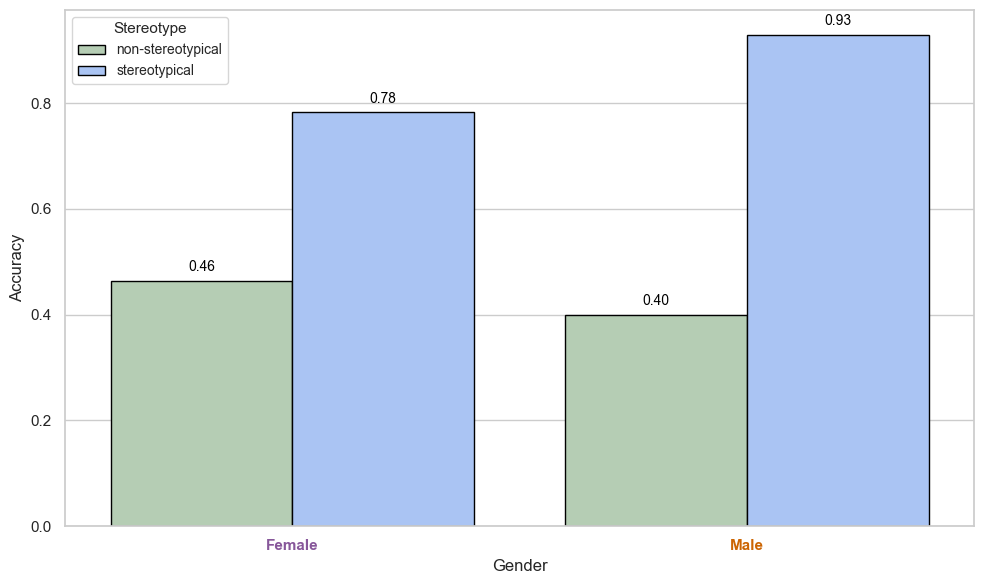

In [70]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set the style of seaborn
sns.set(style="whitegrid")

palette = {'non-stereotypical': '#b1d1b0', 'stereotypical': '#9ec1ff'}

# Create the plot
plt.figure(figsize=(10, 6))
barplot = sns.barplot(
    data=accuracy_by_gender_and_stereotype,
    x='gender_label',
    y='correct',
    hue='stereotype',
    palette=palette, 
    edgecolor='black'
)

# Add value annotations on top of each bar
for p in barplot.patches:
    height = p.get_height()
    if height > 0:
        barplot.annotate(f'{height:.2f}',
                         (p.get_x() + p.get_width() / 2., height),
                         ha='center', va='bottom',
                         fontsize=10, color='black', xytext=(0, 5),
                         textcoords='offset points')

# Labeling
plt.ylabel('Accuracy', fontsize=12)
plt.xlabel('Gender', fontsize=12)
#plt.title('Accuracy by Gender and Stereotype', fontsize=14, weight='bold')
plt.xticks(rotation=0)
gender_colors = {'Female': '#87579A', 'Male': '#CC6502'}  # pink for female, blue for male

# Color x-axis labels based on gender
for tick_label in barplot.get_xticklabels():
    gender = tick_label.get_text()
    if gender in gender_colors:
        tick_label.set_color(gender_colors[gender])
        tick_label.set_fontweight('bold')
plt.legend(title='Stereotype', title_fontsize=11, fontsize=10)
plt.tight_layout()

plt.show()

In [218]:
from scipy.stats import chi2_contingency

# Copy and create correct column
df = word_projection_df.copy()
df['correct'] = df['gender_label'] == df['prediction']

# Count correct/incorrect for each group
contingency_data = (
    df.groupby(['gender_label', 'stereotype'])['correct']
    .value_counts()
    .unstack(fill_value=0)
    .reset_index()
)

# Rename for clarity
contingency_data.columns.name = None
contingency_data.columns = ['gender_label', 'stereotype', 'incorrect', 'correct']

# Run chi-squared test on correct vs incorrect counts
chi2_stat, p, dof, expected = chi2_contingency(contingency_data[['correct', 'incorrect']])

# Print with 4 decimal places
print(f"Chi-squared test p-value: {p:.4f}")


Chi-squared test p-value: 0.0000


In [25]:
from statsmodels.stats.proportion import proportions_ztest

# Step 1: Prepare clean group data
df = word_projection_df.copy()

# Delete all rows where the profession_variant is 2
df = df[df['profession_variant'] != 2]

df['correct'] = df['gender_label'] == df['prediction']

group_stats = (
    df.groupby(['gender_label', 'stereotype'])['correct']
    .agg(['sum', 'count'])  # sum = correct, count = total
    .reset_index()
)

# Step 2: Map readable labels
group_stats['label'] = group_stats.apply(
    lambda row: f"{'Female' if row['gender_label'] == 0 else 'Male'}-{row['stereotype']}", axis=1
)

# Step 3: Build a lookup dictionary for easy access
group_dict = {
    row['label']: {'correct': row['sum'], 'total': row['count']}
    for _, row in group_stats.iterrows()
}

# Step 4: Define pairs of interest
pairs_to_compare = [
    ("Female-non-stereotypical", "Female-stereotypical"),
    ("Female-non-stereotypical", "Male-non-stereotypical"),
    ("Female-stereotypical", "Male-stereotypical"),
    ("Male-non-stereotypical", "Male-stereotypical")
]

# Step 5: Run z-tests only for those pairs
for label1, label2 in pairs_to_compare:
    count = [group_dict[label1]['correct'], group_dict[label2]['correct']]
    nobs = [group_dict[label1]['total'], group_dict[label2]['total']]
    z_stat, p_val = proportions_ztest(count, nobs)
    print(f"{label1} vs {label2} → z = {z_stat:.4f}, p = {p_val:.4f}")


Female-non-stereotypical vs Female-stereotypical → z = -15.8492, p = 0.0000
Female-non-stereotypical vs Male-non-stereotypical → z = 2.5677, p = 0.0102
Female-stereotypical vs Male-stereotypical → z = -7.5825, p = 0.0000
Male-non-stereotypical vs Male-stereotypical → z = -19.1592, p = 0.0000


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


## Calculating bias per stereotype, gender and profession variant

In [26]:
# Copy and add correct prediction column
df = word_projection_df.copy()

# Delete all rows where the profession_variant is 2
df = df[df['profession_variant'] != 2]
df['correct'] = df['gender_label'] == df['prediction']

# Calculate accuracy
accuracy = (
    df.groupby(['gender_label', 'stereotype', 'profession_variant'])['correct']
    .mean()
    .reset_index()
)

# Calculate count
count = (
    df.groupby(['gender_label', 'stereotype', 'profession_variant'])
    .size()
    .reset_index(name='count')
)

# Merge accuracy and count
accuracy_with_count = accuracy.merge(count, on=['gender_label', 'stereotype', 'profession_variant'])

# Map gender_label for readability
accuracy_with_count['gender_label'] = accuracy_with_count['gender_label'].map({0: 'Female', 1: 'Male'})

# Map profession_variant for readability
accuracy_with_count['profession_variant'] = accuracy_with_count['profession_variant'].map({0: 'Female-coded', 1: 'Male-coded'})

# Display
print(accuracy_with_count)

  gender_label         stereotype profession_variant   correct  count
0       Female  non-stereotypical       Female-coded  0.834000    500
1       Female  non-stereotypical         Male-coded  0.092000    500
2       Female      stereotypical       Female-coded  0.969231    650
3       Female      stereotypical         Male-coded  0.595385    650
4         Male  non-stereotypical         Male-coded  0.400285    702
5         Male      stereotypical         Male-coded  0.929630    540


In [222]:
from scipy.stats import chi2_contingency

# Create a summary table
contingency_data = (
    df
    .groupby(['gender_label', 'stereotype', 'profession_variant'])['correct']
    .value_counts()
    .unstack(fill_value=0)
    .reset_index()
)

# Rename for clarity
contingency_data.columns.name = None
contingency_data.columns = ['gender_label', 'stereotype', 'profession_variant', 'incorrect', 'correct']

# Drop unnecessary if needed
# Run chi-square test
chi2_stat, p, dof, expected = chi2_contingency(contingency_data[['correct', 'incorrect']])
print(f"Chi-squared test p-value: {p:.4f}")


Chi-squared test p-value: 0.0000


In [29]:
import pandas as pd

# Make a copy so we don't alter the original
df = accuracy_with_count.copy()

# Ensure columns list is in sync with DataFrame
columns = ["gender_label", "stereotype", "profession_variant", "correct", "count"]

# Create average row with weighting
def average_rows_weighted(rows, label):
    sub_df = df.loc[rows]
    total_count = sub_df['count'].sum()
    weighted_correct = (sub_df['correct'] * sub_df['count']).sum() / total_count
    return pd.Series([label, '', '', weighted_correct, total_count], index=columns)

# Compute weighted averages
avg_non_stereo_female = average_rows_weighted([0, 1], "Female (non-stereotypical avg)")
avg_stereo_female = average_rows_weighted([2, 3], "Female (stereotypical avg)")
avg_non_stereo_male = average_rows_weighted([4], "Male (non-stereotypical avg)")
avg_stereo_male     = average_rows_weighted([5], "Male (stereotypical avg)")

# Indent individual rows
for i in [0, 1, 2, 3]:
    df.loc[i, 'gender_label'] = "  └── Female"
for i in [4]:
    df.loc[i, 'gender_label'] = "  └── Male"
for i in [5]:
    df.loc[i, 'gender_label'] = "  └── Male"

# Build the final structure
final_df = pd.DataFrame([avg_non_stereo_female])
final_df = pd.concat([final_df, df.loc[[0, 1]]], ignore_index=True)

final_df = pd.concat([final_df, pd.DataFrame([avg_stereo_female])], ignore_index=True)
final_df = pd.concat([final_df, df.loc[[2, 3]]], ignore_index=True)

final_df = pd.concat([final_df, pd.DataFrame([avg_non_stereo_male])], ignore_index=True)
final_df = pd.concat([final_df, df.loc[[4]]], ignore_index=True)

final_df = pd.concat([final_df, pd.DataFrame([avg_stereo_male])], ignore_index=True)
final_df = pd.concat([final_df, df.loc[[5]]], ignore_index=True)

final_df


,gender_label,stereotype,profession_variant,correct,count
0,Female (non-stereotypical avg),,,0.463000,1000
1,└── Female,non-stereotypical,Female-coded,0.834000,500
2,└── Female,non-stereotypical,Male-coded,0.092000,500
3,Female (stereotypical avg),,,0.782308,1300
4,└── Female,stereotypical,Female-coded,0.969231,650
5,└── Female,stereotypical,Male-coded,0.595385,650
6,Male (non-stereotypical avg),,,0.400285,702
7,└── Male,non-stereotypical,Male-coded,0.400285,702
8,Male (stereotypical avg),,,0.929630,540
9,└── Male,stereotypical,Male-coded,0.929630,540


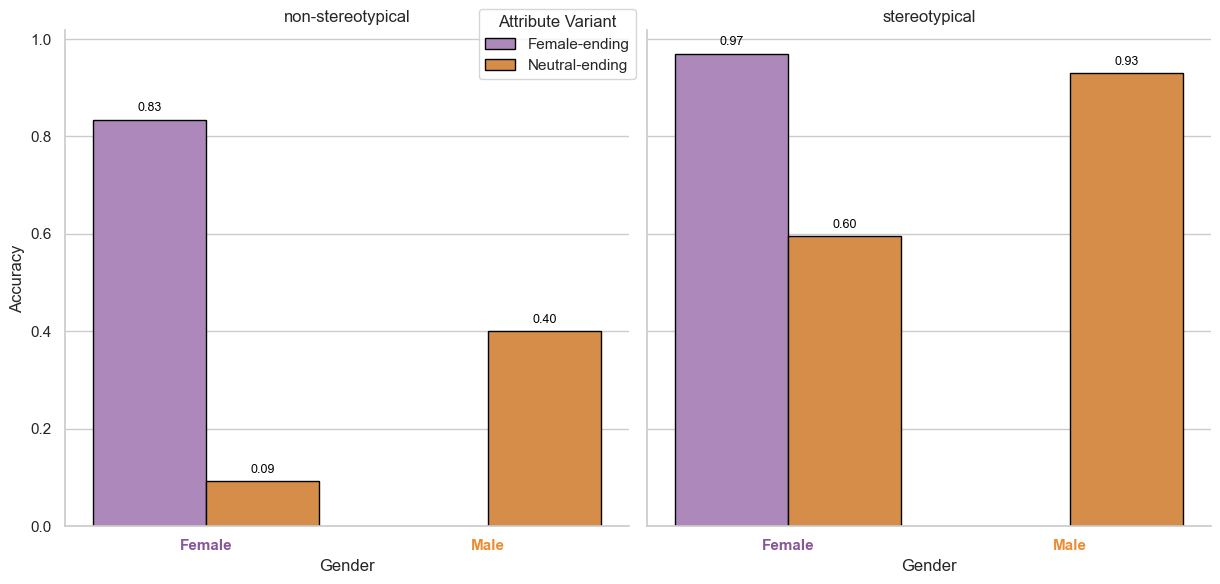

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set style
sns.set(style="whitegrid")

# Define custom colors
gender_colors = {'Female-ending': '#b180c4', 'Neutral-ending': '#ed8c32'}

# Create the grouped bar plot using catplot
g = sns.catplot(
    data=accuracy_with_count,
    kind="bar",
    x="gender_label",
    y="correct",
    hue="profession_variant",
    col="stereotype",
    palette=gender_colors,
    edgecolor="black",
    height=6,
    aspect=0.9
)

# Annotate bars with values
for ax in g.axes.flat:
    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            ax.annotate(f'{height:.2f}',
                        (p.get_x() + p.get_width() / 2., height),
                        ha='center', va='bottom',
                        fontsize=9, color='black', xytext=(0, 4),
                        textcoords='offset points')

# Set axis labels and titles
g.set_axis_labels("Gender", "Accuracy")
g.set_titles("{col_name}")
g._legend.set_title("Attribute Variant")
g._legend.set_bbox_to_anchor((0.52, 0.9))
g._legend.set_frame_on(True)

# Add text to plot in the top left corner
# Add text only to the first subplot
#g.axes[0, 0].text(
#    x=0.8, y=0.03, s="Not\napplicable", 
#    fontsize=12, ha='center', color='red'
#)
#
#g.axes[0, 1].text(
#    x=0.8, y=0.03, s="Not\napplicable", 
#    fontsize=12, ha='center', color='red'
#)

for ax in g.axes.flat:
    # Loop through tick labels on x-axis
    for label in ax.get_xticklabels():
        if label.get_text() == "Female":
            label.set_color('#87579A')
            label.set_fontweight('bold')
        if label.get_text() == "Male":
            label.set_color('#ed8c32')
            label.set_fontweight('bold')

plt.tight_layout()
plt.show()


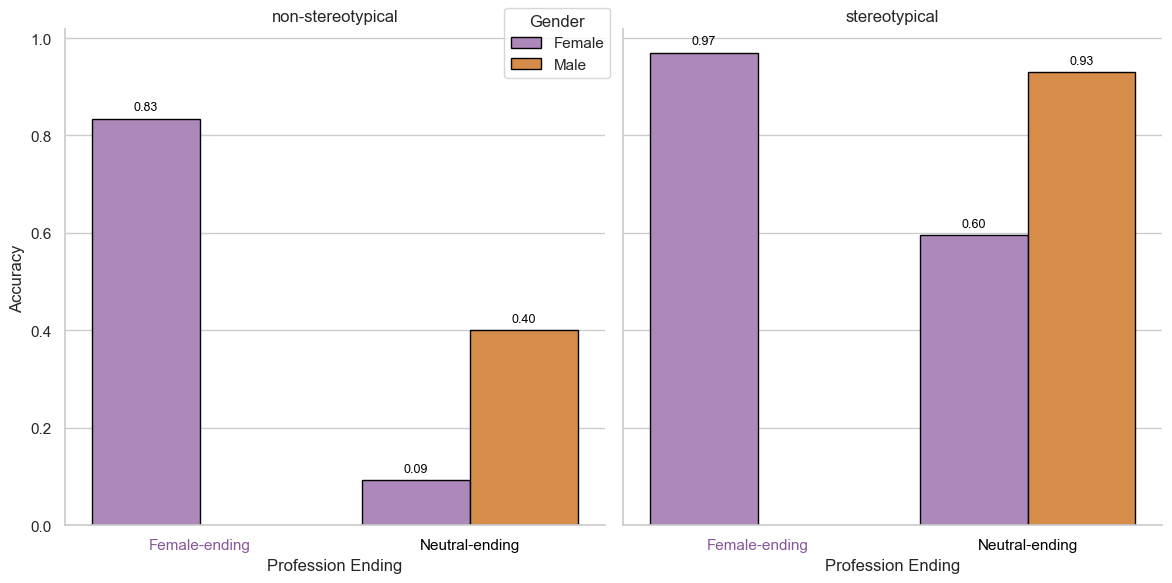

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set style
sns.set(style="whitegrid")

# Replace profession_variant labels in a copy of the DataFrame
accuracy_with_count = accuracy_with_count.copy()
label_map = {'Female-coded': 'Female-ending', 'Male-coded': 'Neutral-ending'}
accuracy_with_count['profession_variant'] = accuracy_with_count['profession_variant'].replace(label_map)

# Define custom colors for gender
gender_colors = {'Female': '#b180c4', 'Male': '#ed8c32'}

# Create the grouped bar plot using catplot
g = sns.catplot(
    data=accuracy_with_count,
    kind="bar",
    x="profession_variant",
    y="correct",
    hue="gender_label",
    col="stereotype",
    palette=gender_colors,
    edgecolor="black",
    height=6,
    aspect=0.9
)

# Annotate bars with values
for ax in g.axes.flat:
    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            ax.annotate(f'{height:.2f}',
                        (p.get_x() + p.get_width() / 2., height),
                        ha='center', va='bottom',
                        fontsize=9, color='black', xytext=(0, 4),
                        textcoords='offset points')

# Set axis labels and titles
g.set_axis_labels("Profession Ending", "Accuracy")
g.set_titles("{col_name}")
g._legend.set_title("Gender")
g._legend.set_bbox_to_anchor((0.52, 0.9))
g._legend.set_frame_on(True)

for ax in g.axes.flat:
    # Loop through tick labels on x-axis
    for label in ax.get_xticklabels():
        if label.get_text() == "Female-ending":
            label.set_color('#87579A')
        else:
            label.set_color('black')

plt.tight_layout()
plt.show()


In [71]:
from statsmodels.stats.proportion import proportions_ztest
import itertools
import pandas as pd

# Step 1: Build labeled group dictionary from your detailed table
group_df = accuracy_with_count.copy()
group_df['label'] = (
    group_df['gender_label'] + '-' +
    group_df['stereotype'] + '-' +
    group_df['profession_variant']
)

# Create lookup dictionary for each group's (correct count, total count)
group_dict = {
    row['label']: {
        'correct': int(row['correct'] * row['count']),
        'total': row['count']
    }
    for _, row in group_df.iterrows()
}

# Step 2: Create all unique pairwise combinations
labels = list(group_dict.keys())
pairs_to_compare = list(itertools.combinations(labels, 2))

# Step 3: Run z-tests
results = []
for label1, label2 in pairs_to_compare:
    count = [group_dict[label1]['correct'], group_dict[label2]['correct']]
    nobs = [group_dict[label1]['total'], group_dict[label2]['total']]
    z_stat, p_val = proportions_ztest(count, nobs)
    results.append({
        'Comparison': f"{label1} vs {label2}",
        'z': round(z_stat, 4),
        'p': f"{p_val:.4f}" if p_val >= 0.0001 else "<0.0001"
    })

# Step 4: Convert to DataFrame and sort by absolute z value (optional)
ztest_df = pd.DataFrame(results).sort_values(by='z', key=abs, ascending=False)

# Display or export
ztest_df


,Comparison,z,p
5,Female-non-stereotypical-Neutral-ending vs Fem...,-29.9600,<0.0001
8,Female-non-stereotypical-Neutral-ending vs Mal...,-27.0320,<0.0001
0,Female-non-stereotypical-Female-ending vs Fema...,23.5286,<0.0001
10,Female-stereotypical-Female-ending vs Male-non...,22.2949,<0.0001
14,Male-non-stereotypical-Neutral-ending vs Male-...,-19.1592,<0.0001
6,Female-non-stereotypical-Neutral-ending vs Fem...,-17.4657,<0.0001
9,Female-stereotypical-Female-ending vs Female-s...,16.3314,<0.0001
3,Female-non-stereotypical-Female-ending vs Male...,15.0199,<0.0001
13,Female-stereotypical-Neutral-ending vs Male-st...,-13.2056,<0.0001
7,Female-non-stereotypical-Neutral-ending vs Mal...,-11.8380,<0.0001


In [72]:
# Keep only the list of Comparison labels of this list
z_tests_to_keep = [
    "Female-non-stereotypical-Female-ending vs Female-non-stereotypical-Neutral-ending",
    "Female-stereotypical-Female-ending vs Female-stereotypical-Neutral-ending",
    "Male-non-stereotypical-Female-ending vs Male-non-stereotypical-Neutral-ending",
    "Male-stereotypical-Female-ending vs Male-stereotypical-Neutral-ending"
]
# Filter the DataFrame
ztest_df_filtered = ztest_df[ztest_df['Comparison'].isin(z_tests_to_keep)]
ztest_df_filtered


,Comparison,z,p
0,Female-non-stereotypical-Female-ending vs Fema...,23.5286,<0.0001
9,Female-stereotypical-Female-ending vs Female-s...,16.3314,<0.0001


## Calculating difference in accuracy between stereotype and non-stereotype sentences

In [73]:
# 1. Overall accuracy
# Delete all rows where the profession_variant is 2
word_projection_df_no2 = word_projection_df[word_projection_df['profession_variant'] != 2]

overall_accuracy = (word_projection_df_no2['prediction'] == word_projection_df_no2['gender_label']).mean()
print(f"Overall accuracy: {overall_accuracy:.2%}")

# 2. Accuracy for stereotypical
stereotypical_df = word_projection_df_no2[word_projection_df_no2['stereotype'] == 'stereotypical']
stereotypical_accuracy = (stereotypical_df['prediction'] == stereotypical_df['gender_label']).mean()
print(f"Stereotypical accuracy: {stereotypical_accuracy:.2%}")

# 3. Accuracy for non-stereotypical
non_stereotypical_df = word_projection_df_no2[word_projection_df_no2['stereotype'] == 'non-stereotypical']
non_stereotypical_accuracy = (non_stereotypical_df['prediction'] == non_stereotypical_df['gender_label']).mean()
print(f"Non-stereotypical accuracy: {non_stereotypical_accuracy:.2%}")


Overall accuracy: 63.89%
Stereotypical accuracy: 82.55%
Non-stereotypical accuracy: 43.71%


In [74]:
from statsmodels.stats.proportion import proportions_ztest

# Get counts of correct predictions
stereo_correct = (stereotypical_df['prediction'] == stereotypical_df['gender_label']).sum()
non_stereo_correct = (non_stereotypical_df['prediction'] == non_stereotypical_df['gender_label']).sum()

# Total number of samples
stereo_n = len(stereotypical_df)
non_stereo_n = len(non_stereotypical_df)

# Run two-proportion z-test
count = [stereo_correct, non_stereo_correct]
nobs = [stereo_n, non_stereo_n]

z_stat, p_value = proportions_ztest(count, nobs)

# Print results
print(f"Z-statistic: {z_stat:.4f}")
print(f"P-value: {p_value:.4f}")


Z-statistic: 24.0451
P-value: 0.0000


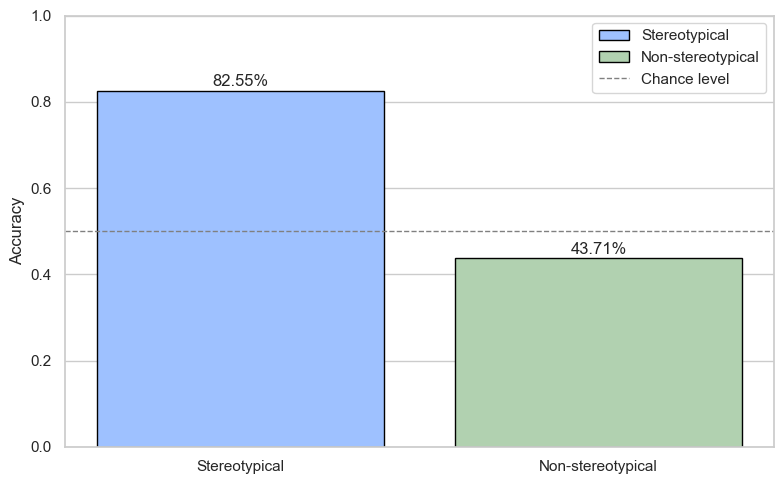

In [75]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Accuracy values
accuracies = [stereotypical_accuracy, non_stereotypical_accuracy]
labels = ['Stereotypical', 'Non-stereotypical']
colors = ['#9ec1ff', '#b1d1b0']

# Bar plot
plt.figure(figsize=(8, 5))
bars = plt.bar(labels, accuracies, edgecolor='black', color=colors)

# Add value labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01, f'{height:.2%}', ha='center')

# Styling
plt.ylim(0, 1)
plt.ylabel('Accuracy')
plt.axhline(0.5, color='gray', linestyle='--', linewidth=1, label='Chance level')

# Custom legend
custom_legend = [
    Patch(facecolor=colors[0], edgecolor='black', label='Stereotypical'),
    Patch(facecolor=colors[1], edgecolor='black', label='Non-stereotypical'),
    plt.Line2D([0], [0], color='gray', linestyle='--', linewidth=1, label='Chance level')
]

plt.legend(handles=custom_legend)
plt.grid(axis='x', visible=False)
plt.tight_layout()
plt.show()


## Plotting the professions on the svm-derived gender axis for neutral sentences

This way, we can see whether the variant of the profession (female or male) are inherently more gendered, showing that maybe for example male is the default

In [89]:
# Copy word_projection_df
df = word_projection_df.copy()

# Create a column for absolute projection (bias magnitude)
df['abs_projection'] = df['word_projection'].abs()

# Group by profession_variant and take the mean of the magnitudes
bias_per_gender = df.groupby('profession_variant')['abs_projection'].mean()

print(bias_per_gender)

profession_variant
0.0    1.204570
1.0    0.923359
2.0    1.103704
Name: abs_projection, dtype: float64


In [90]:
print(df['profession_variant'].unique())

# Get all rows of profession variants where the value is nan
nan_rows = df[df['profession_variant'].isna()]
print(nan_rows)

[1. 0. 2.]
Empty DataFrame
Columns: [gendered_word, gender_label, Beroep, gender_bias, sentence, stereotype, profession_variant, profession_phrase, word_projection, prediction, abs_projection]
Index: []


Final model loaded.


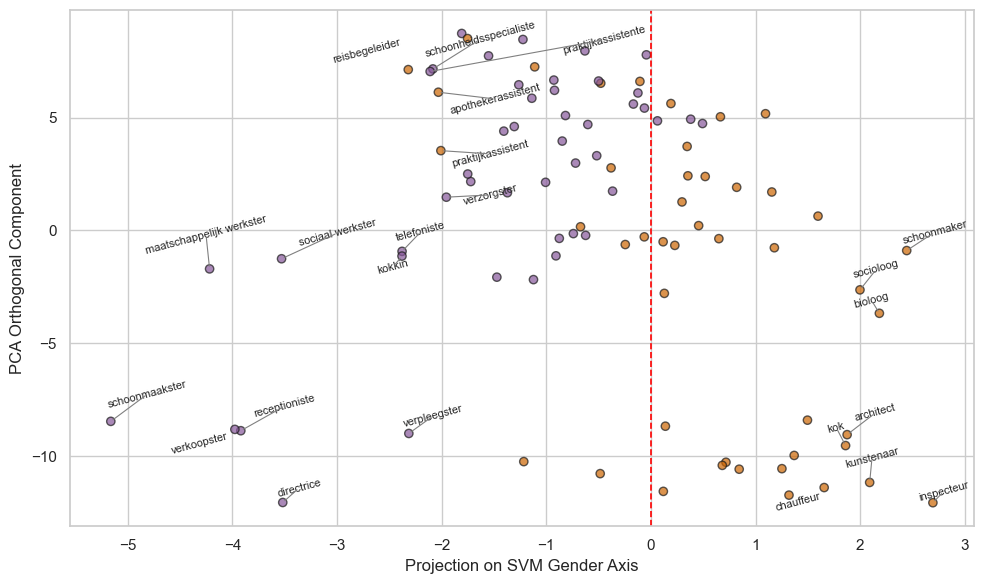

In [91]:
import numpy as np
import matplotlib.pyplot as plt
import joblib
from sklearn.decomposition import PCA
from adjustText import adjust_text
from matplotlib.transforms import Bbox

# Load final model
final_model_path = "svm_models_checkpoint100_BERT/svm_final_model.joblib"
final_model = joblib.load(final_model_path)
weight_vector = final_model.coef_[0]
print("Final model loaded.")

# Load in sentences and embeddings
embeddings_neutral = np.load("../out/profession_embeddings_neutral.npy")
labels_neutral = np.load("../out/profession_labels_neutral.npy")
sentences_neutral = np.load("../out/profession_sentences_neutral.npy")
gender_labels_neutral = np.load("../out/profession_gender_labels_neutral.npy", allow_pickle=True)
gender_bias_neutral = np.load("../out/profession_gender_bias_neutral.npy", allow_pickle=True)
profession_variants_neutral = np.load("../out/profession_profession_variants_neutral.npy", allow_pickle=True)

# Filter sentences starting with "Het is een"
mask = np.array([s.startswith("Het is een") for s in sentences_neutral])

# Apply mask to all relevant arrays
embeddings = embeddings_neutral[mask]
labels = labels_neutral[mask]
sentences = sentences_neutral[mask]
gender_labels = gender_labels_neutral[mask]
gender_biases = gender_bias_neutral[mask]
profession_variants = profession_variants_neutral[mask]

# replace nan values with 0
profession_variants = np.nan_to_num(profession_variants, nan=0)

# Keep only entries where profession_variant is 0 or 1
valid_mask = (profession_variants == 0) | (profession_variants == 1)

# Apply mask to all relevant arrays
embeddings = embeddings[valid_mask]
labels = labels[valid_mask]
sentences = sentences[valid_mask]
gender_labels = gender_labels[valid_mask]
gender_biases = gender_biases[valid_mask]
profession_variants = profession_variants[valid_mask]

sentences = np.array([s.replace("Het is een ", "", 1) for s in sentences])

# Normalize SVM direction
gender_axis = weight_vector / np.linalg.norm(weight_vector)

projections = embeddings @ gender_axis
residuals = embeddings - np.outer(projections, gender_axis)

# Now use PCA on residuals to find the main orthogonal direction
pca = PCA(n_components=1)
orthogonal_axis = pca.fit_transform(residuals).flatten()

# Combine projections and orthogonal axis
X_2d = np.vstack([projections, orthogonal_axis]).T

# Create plot
plt.figure(figsize=(10, 6))
colors = [
    '#87579A' if profession_variant == 0
    else '#CC6502' if profession_variant == 1
    else 'yellow'
    for profession_variant in profession_variants
]

plt.scatter(X_2d[:, 0], X_2d[:, 1], c=colors, alpha=0.7, edgecolor='k')
plt.axvline(x=0, color='red', linestyle='--', linewidth=1.2)  # Decision boundary

#plt.suptitle("2D Projection with SVM Gender Direction (x-axis)", fontsize=14)
#plt.title("Professions plotted by gendered word form: female variants (pink) appear further from the SVM-derived \ngender axis (x=0), revealing that male forms are closer to neutral and often serve as the linguistic default in Dutch.\n", fontsize=10)
plt.xlabel("Projection on SVM Gender Axis")
plt.ylabel("PCA Orthogonal Component")
plt.grid(True)

# Annotate a few extreme points
sorted_indices = np.argsort(X_2d[:, 0])

# Define the subset of indices you're labeling
label_indices = list(sorted_indices[:15]) + list(sorted_indices[-8:])

# Create text objects
texts = [
    plt.text(X_2d[i, 0], X_2d[i, 1], sentences[i], fontsize=8, ha='center', rotation=15)
    for i in label_indices
]

# Force draw so text positions are available
fig = plt.gcf()
fig.canvas.draw()

# Adjust labels and capture arrows
positions, arrows = adjust_text(
    texts,
    arrowprops=dict(arrowstyle='-', color='gray', lw=0.8),
    return_positions=True
)

# Get bounding boxes (in display coords)
bbox_list = [text.get_window_extent() for text in texts]

# Track overlaps and hide one of each overlapping pair
hidden = set()
for i in range(len(bbox_list)):
    for j in range(i + 1, len(bbox_list)):
        if bbox_list[i].overlaps(bbox_list[j]):
            hidden.add(j)

# Hide overlapping texts and their arrows
for i in hidden:
    texts[i].set_visible(False)
    if arrows[i]:
        arrows[i].set_visible(False)

plt.tight_layout()
plt.show()


In [92]:
# Calculate how far each point is from the decision boundary, absolute value
distances = np.abs(X_2d[:, 0])
print(len(distances))

print(len(profession_variants))

# Calculate the mean distance for each profession variant
mean_distances = {}
for variant in np.unique(profession_variants):
    mean_distances[variant] = np.mean(distances[profession_variants == variant])

# print the mean distances
print("Mean distances for each profession variant:")
for variant, mean_distance in mean_distances.items():
    print(f"Profession variant {variant}: {mean_distance:.4f}")

female_distances = distances[profession_variants == 0]
male_distances = distances[profession_variants == 1]
print(female_distances)
print(len(female_distances))
print(male_distances)
print(len(male_distances))

# Perform t-test
from scipy.stats import ttest_ind

# Perform two-sample t-test (Welch's t-test, which does not assume equal variance)
t_stat, p_value = ttest_ind(female_distances, male_distances, equal_var=False)

print(f"T-statistic: {t_stat}")
print(f"P-value: {p_value}")

92
92
Mean distances for each profession variant:
Profession variant 0.0: 1.4567
Profession variant 1.0: 1.0304
[1.80797976 1.95480465 1.26255144 1.7215601  0.36627321 0.71996199
 1.13788834 3.51825216 2.08331566 3.91891851 3.97588005 1.47216546
 0.87545846 2.37806882 2.1098587  3.52961855 5.16137957 2.31329364
 1.37136187 4.21735697 0.63076342 0.84750532 0.49977083 0.04359078
 0.51781811 1.22288704 2.37880418 1.30585172 1.75050372 0.60285868
 0.90734412 1.12227999 0.4930686  0.62378576 0.0626621  0.38008576
 0.74100247 0.16755901 0.06203849 0.12403674 1.00648188 1.55154776
 0.92136646 0.92758807 0.81653339 1.40576318]
46
[0.06348516 0.11875962 1.1105518  1.1553581  0.64942135 0.19130533
 0.71718657 2.03114202 2.00716748 1.99782977 0.48459385 0.13832587
 0.67260562 1.21489025 0.35345887 0.24501431 0.11680153 0.47933683
 2.44450217 0.3460343  0.81957995 0.66434645 0.10500172 0.51888139
 1.75185349 1.87495521 1.17970648 0.84362568 1.25199448 2.18331123
 0.29714129 2.69470317 1.36909714 1

In [93]:
import numpy as np

# Calculate means and standard deviations
mean1 = np.mean(female_distances)
mean2 = np.mean(male_distances)
std1 = np.std(female_distances, ddof=1)
std2 = np.std(male_distances, ddof=1)

# Pooled standard deviation
n1 = len(female_distances)
n2 = len(male_distances)
pooled_std = np.sqrt(((n1 - 1)*std1**2 + (n2 - 1)*std2**2) / (n1 + n2 - 2))

# Cohen's d
cohen_d = (mean1 - mean2) / pooled_std
print(f"Cohen's d: {cohen_d:.4f}")


Cohen's d: 0.4217


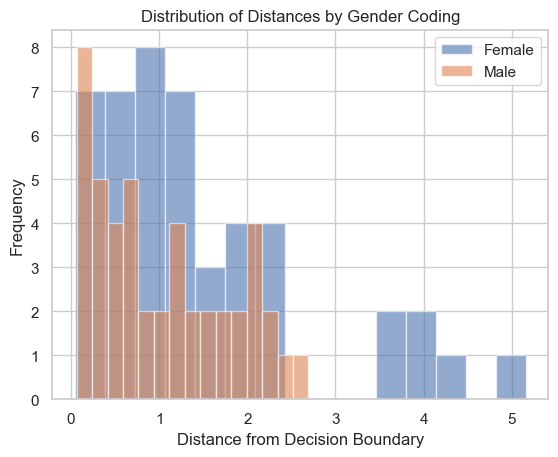

In [94]:
import matplotlib.pyplot as plt

plt.hist(female_distances, bins=15, alpha=0.6, label="Female")
plt.hist(male_distances, bins=15, alpha=0.6, label="Male")
plt.legend()
plt.title("Distribution of Distances by Gender Coding")
plt.xlabel("Distance from Decision Boundary")
plt.ylabel("Frequency")
plt.show()


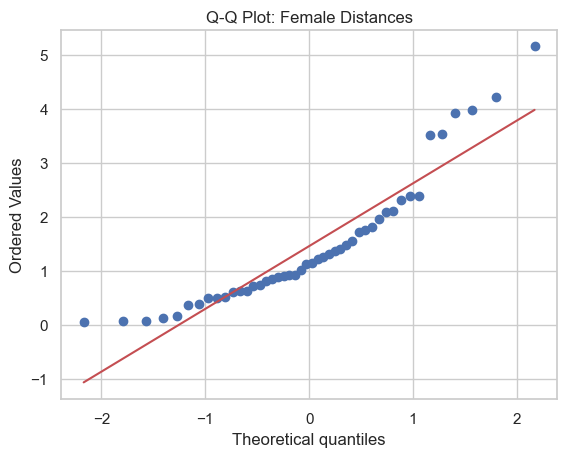

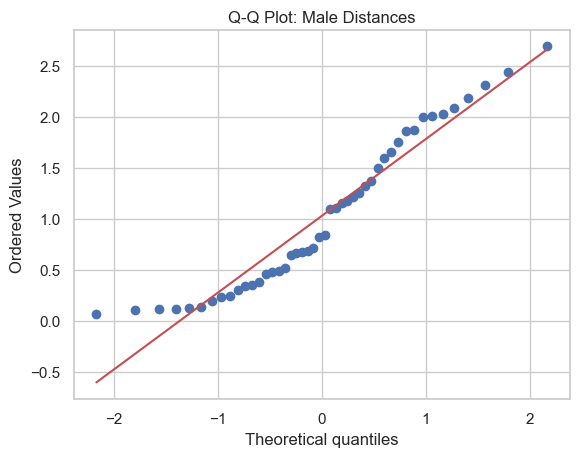

In [95]:
from scipy.stats import probplot

probplot(female_distances, dist="norm", plot=plt)
plt.title("Q-Q Plot: Female Distances")
plt.show()

probplot(male_distances, dist="norm", plot=plt)
plt.title("Q-Q Plot: Male Distances")
plt.show()


In [99]:
from scipy.stats import mannwhitneyu

u_stat, p_val = mannwhitneyu(female_distances, male_distances, alternative='greater')
print(f"Mann-Whitney U statistic: {u_stat}")
print(f"P-value: {p_val}")

effect_size = mannwhitneyu(female_distances, male_distances, method='exact')
print(f"Effect size: {effect_size}")

Mann-Whitney U statistic: 1247.0
P-value: 0.07051279033040771
Effect size: MannwhitneyuResult(statistic=1247.0, pvalue=0.14157698267878546)


In [ ]:
from scipy.stats import mannwhitneyu, norm
import numpy as np

group1 = female_distances
group2 = male_distances

# Run Mann-Whitney U test
u_stat, p_val = mannwhitneyu(group1, group2, alternative='greater', method='asymptotic')

# Sample sizes
n1 = len(group1)
n2 = len(group2)

# Compute mean and standard deviation of U distribution under null
u_mean = n1 * n2 / 2
u_std = np.sqrt(n1 * n2 * (n1 + n2 + 1) / 12)

# Convert U to Z-score
z = (u_stat - u_mean) / u_std

# Compute effect size r
r = z / np.sqrt(n1 + n2)

print(f"U statistic: {u_stat}")
print(f"P-value: {p_val}")
print(f"Z-score: {z}")
print(f"Effect size r: {r}")


U statistic: 1247.0
P-value: 0.07051279033040771
Z-score: 1.4758870470895853
Effect size r: 0.1538718614191556


## For neutral profession terms

In [81]:
# 1. Overall accuracy
# Keep all rows where the profession_variant is 2
word_projection_df_2 = word_projection_df[word_projection_df['profession_variant'] == 2]

overall_accuracy = (word_projection_df_2['prediction'] == word_projection_df_2['gender_label']).mean()
print(f"Overall accuracy: {overall_accuracy:.2%}")

# 2. Accuracy for stereotypical
stereotypical_df = word_projection_df_2[word_projection_df_2['stereotype'] == 'stereotypical']
stereotypical_accuracy = (stereotypical_df['prediction'] == stereotypical_df['gender_label']).mean()
print(f"Stereotypical accuracy: {stereotypical_accuracy:.2%}")

# 3. Accuracy for non-stereotypical
non_stereotypical_df = word_projection_df_2[word_projection_df_2['stereotype'] == 'non-stereotypical']
non_stereotypical_accuracy = (non_stereotypical_df['prediction'] == non_stereotypical_df['gender_label']).mean()
print(f"Non-stereotypical accuracy: {non_stereotypical_accuracy:.2%}")


Overall accuracy: 52.38%
Stereotypical accuracy: 75.58%
Non-stereotypical accuracy: 28.40%


In [82]:
word_projection_df_2

,gendered_word,gender_label,Beroep,gender_bias,sentence,stereotype,profession_variant,profession_phrase,word_projection,prediction
73,De moeder,0,slager,1,De moeder is een slager,non-stereotypical,2.0,slager,0.934861,1
74,De nicht,0,slager,1,De nicht is een slager,non-stereotypical,2.0,slager,0.986889,1
75,De dochter,0,slager,1,De dochter is een slager,non-stereotypical,2.0,slager,0.852912,1
76,De zus,0,slager,1,De zus is een slager,non-stereotypical,2.0,slager,0.874508,1
77,De vrouw,0,slager,1,De vrouw is een slager,non-stereotypical,2.0,slager,1.143178,1
78,Zij,0,slager,1,Zij is een slager,non-stereotypical,2.0,slager,0.685595,1
79,De oma,0,slager,1,De oma is een slager,non-stereotypical,2.0,slager,1.200302,1
88,De kleindochter,0,slager,1,De kleindochter is een slager,non-stereotypical,2.0,slager,-0.080676,0
89,De grootmoeder,0,slager,1,De grootmoeder is een slager,non-stereotypical,2.0,slager,0.811532,1
90,De tante,0,slager,1,De tante is een slager,non-stereotypical,2.0,slager,0.399104,1


In [83]:
from statsmodels.stats.proportion import proportions_ztest

# Get counts of correct predictions
stereo_correct = (stereotypical_df['prediction'] == stereotypical_df['gender_label']).sum()
non_stereo_correct = (non_stereotypical_df['prediction'] == non_stereotypical_df['gender_label']).sum()

# Total number of samples
stereo_n = len(stereotypical_df)
non_stereo_n = len(non_stereotypical_df)

# Run two-proportion z-test
count = [stereo_correct, non_stereo_correct]
nobs = [stereo_n, non_stereo_n]

z_stat, p_value = proportions_ztest(count, nobs)

# Print results
print(f"Z-statistic: {z_stat:.4f}")
print(f"P-value: {p_value:.4f}")


Z-statistic: 23.0951
P-value: 0.0000


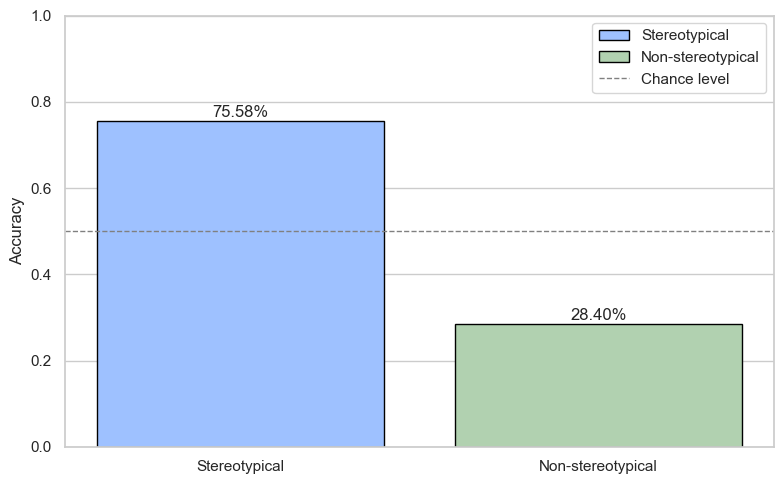

In [84]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Accuracy values
accuracies = [stereotypical_accuracy, non_stereotypical_accuracy]
labels = ['Stereotypical', 'Non-stereotypical']
colors = ['#9ec1ff', '#b1d1b0']

# Bar plot
plt.figure(figsize=(8, 5))
bars = plt.bar(labels, accuracies, edgecolor='black', color=colors)

# Add value labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01, f'{height:.2%}', ha='center')

# Styling
plt.ylim(0, 1)
plt.ylabel('Accuracy')
plt.axhline(0.5, color='gray', linestyle='--', linewidth=1, label='Chance level')

# Custom legend
custom_legend = [
    Patch(facecolor=colors[0], edgecolor='black', label='Stereotypical'),
    Patch(facecolor=colors[1], edgecolor='black', label='Non-stereotypical'),
    plt.Line2D([0], [0], color='gray', linestyle='--', linewidth=1, label='Chance level')
]

plt.legend(handles=custom_legend)
plt.grid(axis='x', visible=False)
plt.tight_layout()
plt.show()

In [85]:
# copy the DataFrame
df = word_projection_df.copy()

# Delete all rows where the profession_variant is 2
df = df[df['profession_variant'] == 2]

# Create a column for correct predictions
df['correct'] = df['gender_label'] == df['prediction']

# Group by gender and stereotype, compute mean accuracy
accuracy_by_gender_and_stereotype = df.groupby(['gender_label', 'stereotype'])['correct'].mean().reset_index()

# Map gender labels to strings for clarity
accuracy_by_gender_and_stereotype['gender_label'] = accuracy_by_gender_and_stereotype['gender_label'].map({0: 'Female', 1: 'Male'})

# Display
print(accuracy_by_gender_and_stereotype)

  gender_label         stereotype   correct
0       Female  non-stereotypical  0.145455
1       Female      stereotypical  0.390769
2         Male  non-stereotypical  0.609687
3         Male      stereotypical  0.888889


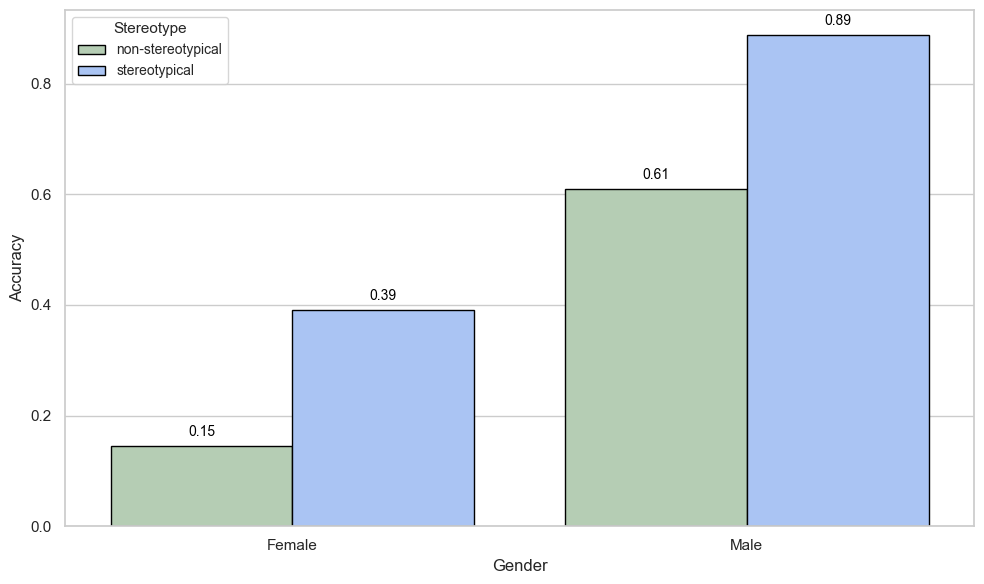

In [86]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set the style of seaborn
sns.set(style="whitegrid")

palette = {'non-stereotypical': '#b1d1b0', 'stereotypical': '#9ec1ff'}

# Create the plot
plt.figure(figsize=(10, 6))
barplot = sns.barplot(
    data=accuracy_by_gender_and_stereotype,
    x='gender_label',
    y='correct',
    hue='stereotype',
    palette=palette, 
    edgecolor='black'
)

# Add value annotations on top of each bar
for p in barplot.patches:
    height = p.get_height()
    if height > 0:
        barplot.annotate(f'{height:.2f}',
                         (p.get_x() + p.get_width() / 2., height),
                         ha='center', va='bottom',
                         fontsize=10, color='black', xytext=(0, 5),
                         textcoords='offset points')

# Labeling
plt.ylabel('Accuracy', fontsize=12)
plt.xlabel('Gender', fontsize=12)
#plt.title('Accuracy by Gender and Stereotype', fontsize=14, weight='bold')
plt.xticks(rotation=0)
plt.legend(title='Stereotype', title_fontsize=11, fontsize=10)
plt.tight_layout()

plt.show()

In [87]:
from statsmodels.stats.proportion import proportions_ztest

# Step 1: Prepare clean group data
df = word_projection_df.copy()

# Delete all rows where the profession_variant is 2
df = df[df['profession_variant'] != 2]

df['correct'] = df['gender_label'] == df['prediction']

group_stats = (
    df.groupby(['gender_label', 'stereotype'])['correct']
    .agg(['sum', 'count'])  # sum = correct, count = total
    .reset_index()
)

# Step 2: Map readable labels
group_stats['label'] = group_stats.apply(
    lambda row: f"{'Female' if row['gender_label'] == 0 else 'Male'}-{row['stereotype']}", axis=1
)

# Step 3: Build a lookup dictionary for easy access
group_dict = {
    row['label']: {'correct': row['sum'], 'total': row['count']}
    for _, row in group_stats.iterrows()
}

# Step 4: Define pairs of interest
pairs_to_compare = [
    ("Female-non-stereotypical", "Female-stereotypical"),
    ("Female-non-stereotypical", "Male-non-stereotypical"),
    ("Female-stereotypical", "Male-stereotypical"),
    ("Male-non-stereotypical", "Male-stereotypical")
]

# Step 5: Run z-tests only for those pairs
for label1, label2 in pairs_to_compare:
    count = [group_dict[label1]['correct'], group_dict[label2]['correct']]
    nobs = [group_dict[label1]['total'], group_dict[label2]['total']]
    z_stat, p_val = proportions_ztest(count, nobs)
    print(f"{label1} vs {label2} → z = {z_stat:.4f}, p = {p_val:.4f}")


Female-non-stereotypical vs Female-stereotypical → z = -15.8492, p = 0.0000
Female-non-stereotypical vs Male-non-stereotypical → z = 2.5677, p = 0.0102
Female-stereotypical vs Male-stereotypical → z = -7.5825, p = 0.0000
Male-non-stereotypical vs Male-stereotypical → z = -19.1592, p = 0.0000
